In [21]:
# Cell 0: Library imports
import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, ttest_ind

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

pd.set_option("display.width", 120)

In [22]:
# Cell 1: Global configuration
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
ENV_PATH = "data_pendukung/data_lingkungan.csv"
COORDS_PATH = "data_pendukung/koordinat_pos.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"

TARGET_HOURS = [6, 12, 18]
TRAIN_TEST_CUTOFF = pd.Timestamp("2025-09-19")

In [23]:
# Cell 2: Load raw datasets
df = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
env = pd.read_csv(ENV_PATH)

df["datetime_parsed"] = pd.to_datetime(df["datetime"])
env["datetime_parsed"] = pd.to_datetime(env["datetime"])

print("train:", df.shape)
print("test :", test.shape)
print("env  :", env.shape)

train: (84396, 4)
test : (21780, 1)
env  : (888480, 28)


In [24]:
# Cell 3: Structural inspection of train and env
print("--- train.csv ---")
print(df.dtypes)
print(df.isnull().sum())
print(f"Stations: {df['nama_pos'].nunique()}")
print(f"Datetime range: {df['datetime'].min()} - {df['datetime'].max()}")

print("\n--- data_lingkungan.csv ---")
print(env.dtypes)
print(env.isnull().sum())
print(f"Stations: {env['nama_pos'].nunique()}")
print(f"Datetime range: {env['datetime'].min()} - {env['datetime'].max()}")
print(f"Duplicate (datetime, nama_pos) rows: {env.duplicated(subset=['datetime', 'nama_pos']).sum()}")

--- train.csv ---
datetime                      str
nama_pos                      str
tma_mdpl                  float64
datetime_parsed    datetime64[us]
dtype: object
datetime           0
nama_pos           0
tma_mdpl           0
datetime_parsed    0
dtype: int64
Stations: 30
Datetime range: 2023-01-01 06:00:00 - 2025-09-18 18:00:00

--- data_lingkungan.csv ---
datetime                              str
nama_pos                              str
rainfall_mm                       float64
humidity_pct                        int64
wind_direction_deg                  int64
dew_point_c                       float64
cloud_cover_pct                     int64
temperature_c                     float64
wind_speed_kmh                    float64
rainfall_openmeteo_mm             float64
rainfall_max_24h_mm               float64
solar_radiation_mj_m2             float64
soil_moisture_0_7cm               float64
soil_moisture_7_28cm              float64
soil_moisture_28_100cm            float64
soil_

In [25]:
# Cell 4: Expected vs actual observation counts per station
def missing_timestamps(sub, hours=TARGET_HOURS):
    """Compare observed timestamps against the expected 6-hourly grid."""
    start = sub["datetime_parsed"].min().normalize()
    end = sub["datetime_parsed"].max().normalize()
    expected = pd.Series(
        [d + pd.Timedelta(hours=h) for d in pd.date_range(start, end, freq="D") for h in hours]
    )
    actual = set(sub["datetime_parsed"])
    return expected[~expected.isin(actual)]

row_counts = df.groupby("nama_pos").size().sort_values()
print("Row count per station (lowest 10):")
print(row_counts.head(10))

suspect_stations = row_counts.head(3).index.tolist()
for pos in suspect_stations:
    sub = df[df["nama_pos"] == pos].sort_values("datetime_parsed")
    missing = missing_timestamps(sub)
    print(f"\n{pos}: expected={len(sub) + len(missing)}, actual={len(sub)}, missing={len(missing)}")
    if len(missing):
        print(missing.dt.to_period("M").value_counts().sort_index())

Row count per station (lowest 10):
nama_pos
Gunungsari                   1126
Floodway Bridge C            2377
Bojonegoro - Kali Kethek     2688
Babat                        2838
Jarum                        2864
Sumberrejo                   2878
Cepu                         2893
Kali Pepe - Tugu Boto        2900
Kali Pepe - PTPN             2901
Kali Anyar - Kreteg Abang    2901
dtype: int64

Gunungsari: expected=1206, actual=1126, missing=80
2024-08     5
2025-02    75
Freq: M, Name: count, dtype: int64

Floodway Bridge C: expected=2976, actual=2377, missing=599
2023-06     2
2023-08    63
2023-09    90
2023-10    93
2023-11    90
2023-12    93
2024-01    93
2025-02    75
Freq: M, Name: count, dtype: int64

Bojonegoro - Kali Kethek: expected=2976, actual=2688, missing=288
2023-07    86
2023-08    92
2023-09    19
2023-10     1
2023-12     1
2024-03     1
2025-02    75
2025-03    13
Freq: M, Name: count, dtype: int64


In [26]:
# Cell 5: Confirm the outage is dataset-wide, not station-specific
feb2025 = df[(df["datetime_parsed"] >= "2025-02-01") & (df["datetime_parsed"] < "2025-03-01")]
feb_counts = feb2025.groupby("nama_pos").size().sort_values()
expected_feb = 28 * len(TARGET_HOURS)

print(f"Expected Feb-2025 observations per station: {expected_feb}")
print("Stations below 80% of expectation:")
print(feb_counts[feb_counts < expected_feb * 0.8])

print("\nObservations per calendar day in Feb 2025 (all stations):")
print(feb2025.groupby(feb2025["datetime_parsed"].dt.date).size())

Expected Feb-2025 observations per station: 84
Stations below 80% of expectation:
nama_pos
Babat                         9
Badegan                       9
Bengkelolor                   9
Bojonegoro - Kali Kethek      9
Cepu                          9
Brangkal                      9
Gunungsari                    9
Floodway Bridge C             9
Kali Pepe - PTPN              9
Kali Anyar - Kreteg Abang     9
Jarum                         9
Kajangan                      9
Ketonggo                      9
Kedungupit                    9
Karangnongko                  9
Kali Pepe - Tugu Boto         9
Wonogiri Dam                  9
Sekayu                        9
Serenan                       9
Sumberrejo                    9
Napel                         9
Lorog                         9
Ngadipiro                     9
Ngrembang                     9
Peren                        10
Boboh Kali Lamong            10
Arjowinangun - Pacitan       11
Colo Weir                    11
Jurug        

In [27]:
# Cell 6: Target distribution, per-station stats, and anomalies
print("Overall stats:")
print(df["tma_mdpl"].describe())
print(f"Skewness: {df['tma_mdpl'].skew():.3f} | Kurtosis: {df['tma_mdpl'].kurtosis():.3f}")

stats_per_pos = df.groupby("nama_pos")["tma_mdpl"].agg(
    ["count", "mean", "std", "min", "max", "skew"]
).sort_values("mean", ascending=False)
print("\nPer-station stats:")
print(stats_per_pos)

n_invalid = (df["tma_mdpl"] <= 0).sum()
print(f"\nInvalid readings (tma_mdpl <= 0): {n_invalid}")
print(df[df["tma_mdpl"] <= 0][["datetime", "nama_pos", "tma_mdpl"]])

print("\nTop 10 highest readings:")
print(df.nlargest(10, "tma_mdpl")[["datetime", "nama_pos", "tma_mdpl"]])

Overall stats:
count    84396.000000
mean        56.482537
std         46.765914
min         -0.059668
25%         10.100000
50%         50.370000
75%         90.660938
max        325.830000
Name: tma_mdpl, dtype: float64
Skewness: 0.343 | Kurtosis: -1.236

Per-station stats:
                           count        mean       std         min         max       skew
nama_pos                                                                                 
Ngadipiro                   2901  143.562796  0.334947  143.177995  146.310000   2.345721
Ngrembang                   2901  140.050592  0.286869  139.850191  143.790000   5.410370
Wonogiri Dam                2901  132.340343  3.299649  125.539541  137.357083  -0.498430
Badegan                     2901  122.402005  0.309940  121.902101  123.960000   1.224292
Colo Weir                   2903  107.789569  1.119431  102.186332  109.700000  -3.158324
Kali Pepe - Tugu Boto       2900   94.821256  0.448224   94.350666  100.420000   3.905118
Per

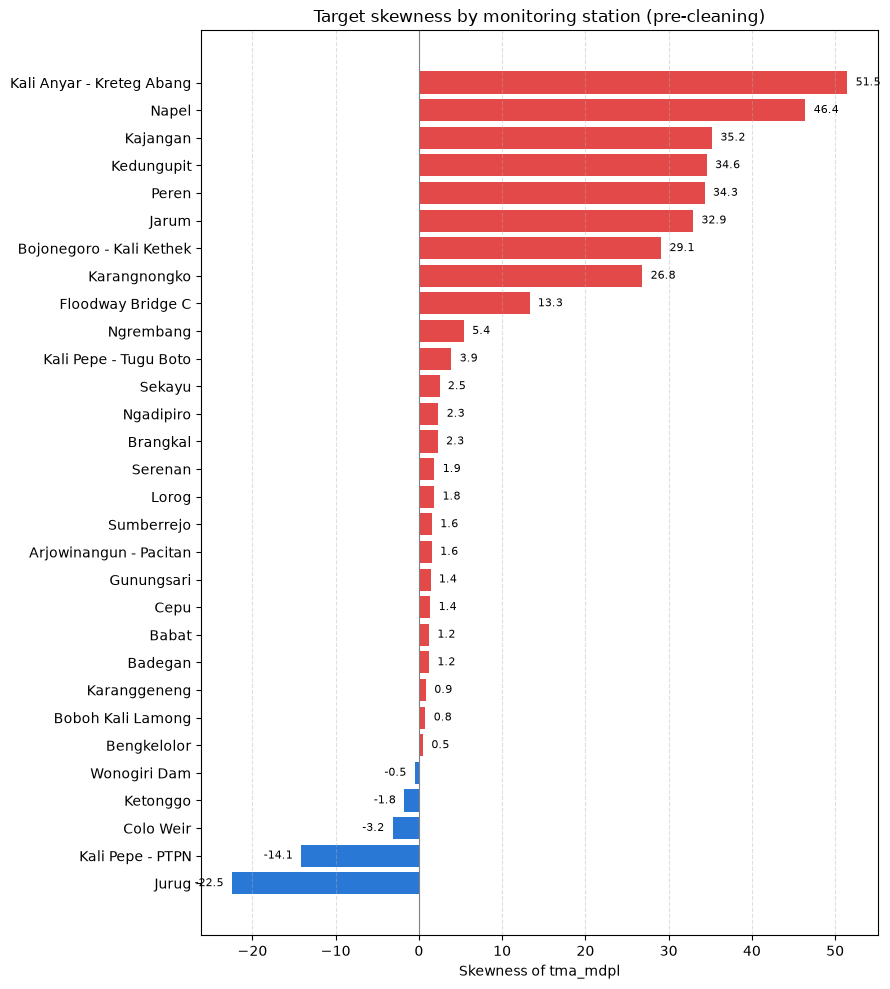

In [28]:
# Cell 7: Skewness per station (visual, pre-cleaning - see Cell 36 for post-cleaning)
skew_per_pos = df.groupby("nama_pos")["tma_mdpl"].skew().sort_values()
colors = ["#2a78d6" if v < 0 else "#e34948" for v in skew_per_pos.values]

fig, ax = plt.subplots(figsize=(9, 10))
bars = ax.barh(skew_per_pos.index, skew_per_pos.values, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Skewness of tma_mdpl")
ax.set_title("Target skewness by monitoring station (pre-cleaning)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
for bar, val in zip(bars, skew_per_pos.values):
    ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
# Cell 8: Investigate and remove the Floodway Bridge C outlier
floodway = df[df["nama_pos"] == "Floodway Bridge C"].sort_values("datetime_parsed")
window = floodway[
    (floodway["datetime_parsed"] >= "2025-06-08") & (floodway["datetime_parsed"] <= "2025-06-22")
]
print("Floodway Bridge C, +/-7 days around the spike:")
print(window[["datetime", "tma_mdpl"]].to_string(index=False))
# Single-point spike with no rainfall build-up on either side -> sensor error, not a flood event.

outlier_mask = (df["nama_pos"] == "Floodway Bridge C") & (df["datetime"] == "2025-06-15 18:00:00")
print(f"\nRows removed: {outlier_mask.sum()}")
df = df[~outlier_mask].reset_index(drop=True)
print(f"Max tma_mdpl after removal: {df[df['nama_pos'] == 'Floodway Bridge C']['tma_mdpl'].max():.2f}")

Floodway Bridge C, +/-7 days around the spike:
           datetime  tma_mdpl
2025-06-08 06:00:00  2.500000
2025-06-08 12:00:00  3.000000
2025-06-08 18:00:00  3.081146
2025-06-09 06:00:00  3.300000
2025-06-09 12:00:00  2.898452
2025-06-09 18:00:00  2.500000
2025-06-10 06:00:00  3.000000
2025-06-10 12:00:00  2.500000
2025-06-10 18:00:00  2.250000
2025-06-11 06:00:00  3.200000
2025-06-11 12:00:00  3.071657
2025-06-11 18:00:00  2.500000
2025-06-12 06:00:00  2.500000
2025-06-12 12:00:00  2.558751
2025-06-12 18:00:00  2.500000
2025-06-13 06:00:00  3.066970
2025-06-13 12:00:00  3.000000
2025-06-13 18:00:00  3.500000
2025-06-14 06:00:00  3.800000
2025-06-14 12:00:00  3.800000
2025-06-14 18:00:00  4.000000
2025-06-15 06:00:00  4.431908
2025-06-15 12:00:00  4.700000
2025-06-15 18:00:00 47.000000
2025-06-16 06:00:00  2.434565
2025-06-16 12:00:00  2.500000
2025-06-16 18:00:00  2.500000
2025-06-17 06:00:00  3.000000
2025-06-17 12:00:00  3.500000
2025-06-17 18:00:00  3.800000
2025-06-18 06:00:00  4.

In [30]:
# Cell 9: Missing value patterns in the environmental dataset
missing_soil = env[env["soil_moisture_0_7cm"].isnull()]
print("Dates missing soil moisture / pressure / MJO:")
print(missing_soil["datetime_parsed"].dt.date.value_counts())

missing_nino = env[env["nino_34"].isnull()]
print(f"\nnino_34 missing range: {missing_nino['datetime_parsed'].min()} - {missing_nino['datetime_parsed'].max()}")
print(f"Unique months missing: {missing_nino['datetime_parsed'].dt.to_period('M').nunique()}")

print(f"\nsolar_radiation_mj_m2 == -999: {(env['solar_radiation_mj_m2'] == -999).sum()}")
solar_missing = env[env["solar_radiation_mj_m2"] == -999]
print(f"-999 date range: {solar_missing['datetime_parsed'].min()} - {solar_missing['datetime_parsed'].max()}")

print(f"\nrainfall_mm vs rainfall_openmeteo_mm differing rows: {(env['rainfall_mm'] != env['rainfall_openmeteo_mm']).sum()}")

Dates missing soil moisture / pressure / MJO:
datetime_parsed
2026-05-18    720
Name: count, dtype: int64

nino_34 missing range: 2026-05-01 00:00:00 - 2026-05-18 23:00:00
Unique months missing: 1

solar_radiation_mj_m2 == -999: 100080
-999 date range: 2025-12-31 00:00:00 - 2026-05-18 23:00:00

rainfall_mm vs rainfall_openmeteo_mm differing rows: 0


In [31]:
# Cell 10: Range and sanity checks on numeric environmental features
numeric_cols = [
    "rainfall_mm", "humidity_pct", "wind_direction_deg", "dew_point_c",
    "cloud_cover_pct", "temperature_c", "wind_speed_kmh", "rainfall_max_24h_mm",
    "soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm",
    "soil_moisture_100_255cm", "surface_pressure_hpa", "pressure_msl_hpa",
]
print(env[numeric_cols].describe().T)
print(f"\nrainfall_mm == 0: {(env['rainfall_mm'] == 0).mean():.1%}")

print("\nOut-of-range value checks:")
print(f"  rainfall_mm < 0: {(env['rainfall_mm'] < 0).sum()}")
print(f"  humidity_pct outside [0, 100]: {((env['humidity_pct'] > 100) | (env['humidity_pct'] < 0)).sum()}")
print(f"  cloud_cover_pct outside [0, 100]: {((env['cloud_cover_pct'] > 100) | (env['cloud_cover_pct'] < 0)).sum()}")
print(f"  wind_direction_deg outside [0, 360]: {((env['wind_direction_deg'] > 360) | (env['wind_direction_deg'] < 0)).sum()}")

pressure_check = env.groupby("nama_pos")[["surface_pressure_hpa", "pressure_msl_hpa"]].mean()
pressure_check["diff"] = pressure_check["pressure_msl_hpa"] - pressure_check["surface_pressure_hpa"]
print("\nsurface vs MSL pressure difference by station (proxy for elevation):")
print(pressure_check.sort_values("diff"))

                            count         mean        std       min       25%       50%       75%       max
rainfall_mm              888480.0     0.277659   1.125519     0.000     0.000     0.000     0.100    40.500
humidity_pct             888480.0    79.821690  15.573497    16.000    71.000    84.000    92.000   100.000
wind_direction_deg       888480.0   186.329979  80.307582     0.000   132.000   190.000   237.000   360.000
dew_point_c              888480.0    22.443110   1.977853     3.500    21.600    23.000    23.800    27.500
cloud_cover_pct          888480.0    75.552184  34.498930     0.000    51.000    98.000   100.000   100.000
temperature_c            888480.0    26.622536   3.020016    17.500    24.400    25.900    28.600    38.800
wind_speed_kmh           888480.0     8.292797   5.173759     0.000     4.300     7.200    11.300    39.200
rainfall_max_24h_mm      888480.0     2.846651   3.822203     0.000     0.100     1.000     4.500    40.500
soil_moisture_0_7cm      887

In [32]:
# Cell 11: Feature granularity checks (MJO, nino_34)
sample = env[env["nama_pos"] == "Arjowinangun - Pacitan"].head(72)
mjo_unique = sample[["mjo_phase", "mjo_amplitude", "rmm1", "rmm2"]].drop_duplicates()
print("Unique MJO/RMM combinations in first 3 days (1 station):")
print(mjo_unique)
# Confirms MJO indices update daily, not hourly, despite being stored per-row.

env["date_only"] = env["datetime_parsed"].dt.date
mjo_per_day = env.groupby(["nama_pos", "date_only"])["mjo_phase"].nunique()
print(f"\nStation-days with more than one mjo_phase value: {(mjo_per_day > 1).sum()}")

nino_per_month = env.groupby(["nama_pos", env["datetime_parsed"].dt.to_period("M")])["nino_34"].nunique()
print(f"Station-months with more than one nino_34 value: {(nino_per_month > 1).sum()}")

same_time = env[env["datetime"] == "2023-06-15 12:00:00"][["nama_pos", "mjo_phase", "nino_34"]]
print(f"\nDistinct mjo_phase values across stations at a fixed timestamp: {same_time['mjo_phase'].nunique()}")
print(f"Distinct nino_34 values across stations at a fixed timestamp: {same_time['nino_34'].nunique()}")

Unique MJO/RMM combinations in first 3 days (1 station):
    mjo_phase  mjo_amplitude      rmm1      rmm2
0         7.0       1.280929 -0.092299  1.277599
24        7.0       1.491283 -0.530987  1.393549
48        7.0       1.470509 -0.505245  1.380987

Station-days with more than one mjo_phase value: 0
Station-months with more than one nino_34 value: 0

Distinct mjo_phase values across stations at a fixed timestamp: 1
Distinct nino_34 values across stations at a fixed timestamp: 1


In [33]:
# Cell 12: Merge on exact-hour match and compare global vs within-station correlation
env_matched = env[env["datetime_parsed"].dt.hour.isin(TARGET_HOURS)].copy()
merged = df.merge(env_matched, on=["datetime", "nama_pos"], how="inner", suffixes=("", "_env"))

print(f"Merged shape: {merged.shape} (train rows dropped: {df.shape[0] - merged.shape[0]})")

numeric_features = [
    "rainfall_mm", "humidity_pct", "wind_direction_deg", "dew_point_c",
    "cloud_cover_pct", "temperature_c", "wind_speed_kmh", "rainfall_max_24h_mm",
    "soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm",
    "soil_moisture_100_255cm", "surface_pressure_hpa", "pressure_msl_hpa",
    "rmm1", "rmm2", "mjo_phase", "mjo_amplitude", "mjo_active", "nino_34",
]

global_corr = merged[numeric_features + ["tma_mdpl"]].corr()["tma_mdpl"].drop("tma_mdpl")

within_pos_corr = pd.Series({
    feat: merged.groupby("nama_pos").apply(
        lambda g: g[feat].corr(g["tma_mdpl"]) if g[feat].notna().sum() > 10 else np.nan
    ).mean()
    for feat in numeric_features
})

comparison = pd.DataFrame({"global_corr": global_corr, "within_pos_corr": within_pos_corr})
print(comparison.sort_values("within_pos_corr", key=abs, ascending=False))

Merged shape: (84395, 31) (train rows dropped: 0)
                         global_corr  within_pos_corr
soil_moisture_7_28cm        0.123752         0.493016
soil_moisture_0_7cm         0.105787         0.457828
soil_moisture_28_100cm      0.126972         0.426724
rainfall_max_24h_mm        -0.025053         0.318331
dew_point_c                -0.121661         0.307533
humidity_pct                0.000427         0.252286
surface_pressure_hpa       -0.947420        -0.222831
cloud_cover_pct             0.000272         0.218694
pressure_msl_hpa            0.097005        -0.214252
nino_34                     0.017773        -0.178379
wind_speed_kmh              0.057336        -0.154964
soil_moisture_100_255cm     0.189416         0.141325
wind_direction_deg          0.063565         0.138174
mjo_amplitude               0.004438         0.134032
temperature_c              -0.076961        -0.114993
rainfall_mm                -0.005300         0.097480
rmm2                        0.00

In [34]:
# Cell 13: Feature redundancy check
soil_cols = ["soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm", "soil_moisture_100_255cm"]
print("Correlation among soil moisture layers:")
print(merged[soil_cols].corr())

full_corr = merged[numeric_features].corr()
corr_pairs = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool)).stack()
high_corr = corr_pairs[abs(corr_pairs) > 0.7].sort_values(key=abs, ascending=False)
print("\nFeature pairs with |correlation| > 0.7 (redundancy candidates):")
print(high_corr)

Correlation among soil moisture layers:
                         soil_moisture_0_7cm  soil_moisture_7_28cm  soil_moisture_28_100cm  soil_moisture_100_255cm
soil_moisture_0_7cm                 1.000000              0.912656                0.676571                 0.350591
soil_moisture_7_28cm                0.912656              1.000000                0.822179                 0.446218
soil_moisture_28_100cm              0.676571              0.822179                1.000000                 0.649102
soil_moisture_100_255cm             0.350591              0.446218                0.649102                 1.000000

Feature pairs with |correlation| > 0.7 (redundancy candidates):
soil_moisture_0_7cm   soil_moisture_7_28cm      0.912656
humidity_pct          temperature_c            -0.884401
soil_moisture_7_28cm  soil_moisture_28_100cm    0.822179
mjo_amplitude         mjo_active                0.732165
dtype: float64


In [35]:
# Cell 14: Autocorrelation and observation spacing
ac_df = pd.DataFrame({
    pos: {
        "lag1": (sub := df[df["nama_pos"] == pos].sort_values("datetime_parsed"))["tma_mdpl"].autocorr(1),
        "lag2": sub["tma_mdpl"].autocorr(2),
        "lag3": sub["tma_mdpl"].autocorr(3),
    }
    for pos in df["nama_pos"].unique()
}).T.sort_values("lag1")
print(ac_df)

sample_pos = df[df["nama_pos"] == "Ngadipiro"].sort_values("datetime_parsed").copy()
sample_pos["time_delta_hours"] = sample_pos["datetime_parsed"].diff().dt.total_seconds() / 3600
print("\nLargest gaps between consecutive readings (Ngadipiro):")
print(sample_pos.nlargest(5, "time_delta_hours")[["datetime", "tma_mdpl", "time_delta_hours"]])

                               lag1      lag2      lag3
Kali Pepe - PTPN           0.008505  0.005684  0.003672
Jarum                      0.023517  0.080493  0.017051
Kali Anyar - Kreteg Abang  0.036410  0.035667  0.035461
Peren                      0.046968  0.041344  0.038105
Karangnongko               0.077873  0.072757  0.069968
Napel                      0.093894  0.089157  0.087480
Bojonegoro - Kali Kethek   0.132707  0.128668  0.122979
Kajangan                   0.224736  0.212641  0.197630
Kedungupit                 0.232626  0.222072  0.205455
Jurug                      0.381485  0.348466  0.345177
Kali Pepe - Tugu Boto      0.610803  0.537642  0.541890
Arjowinangun - Pacitan     0.624031  0.576953  0.797440
Ngrembang                  0.723294  0.632978  0.614603
Ngadipiro                  0.804071  0.739232  0.720664
Lorog                      0.813428  0.769273  0.757251
Ketonggo                   0.815217  0.760106  0.719505
Badegan                    0.851446  0.790909  0

In [36]:
# Cell 15: Seasonal and yearly patterns (station-normalized)
df["month"] = df["datetime_parsed"].dt.month
df["year"] = df["datetime_parsed"].dt.year
df["tma_normalized"] = df.groupby("nama_pos")["tma_mdpl"].transform(lambda x: x - x.mean())

print("Normalized TMA by month:")
print(df.groupby("month")["tma_normalized"].mean())

df_fair = df[df["month"] <= 9].copy()
pivot_check = df_fair.pivot_table(values="tma_normalized", index="month", columns="year", aggfunc="mean")
print("\nNormalized TMA, month x year (Jan-Sep only):")
print(pivot_check)

pos_year_trend = df_fair.groupby(["nama_pos", "year"])["tma_mdpl"].mean().unstack()
pos_year_trend["change_2023_to_2025"] = pos_year_trend[2025] - pos_year_trend[2023]
print("\nPer-station change, 2023 to 2025 (Jan-Sep):")
print(pos_year_trend.sort_values("change_2023_to_2025"))

Normalized TMA by month:
month
1     0.452123
2     1.061813
3     0.991044
4     0.500351
5     0.197376
6    -0.146520
7    -0.418934
8    -0.591153
9    -0.785852
10   -1.092605
11   -0.630286
12    0.187291
Name: tma_normalized, dtype: float64

Normalized TMA, month x year (Jan-Sep only):
year       2023      2024      2025
month                              
1      0.286233  0.116889  0.925369
2      1.608902  0.654964  0.013073
3      1.205108  0.732679  1.035981
4      0.585458  0.413413  0.502121
5      0.224815 -0.371841  0.725061
6     -0.090346 -0.491369  0.132761
7     -0.327168 -0.668166 -0.263856
8     -0.517407 -0.895802 -0.356911
9     -0.776802 -0.905399 -0.600459

Per-station change, 2023 to 2025 (Jan-Sep):
year                             2023        2024        2025  change_2023_to_2025
nama_pos                                                                          
Kali Anyar - Kreteg Abang   87.728864   85.960045   86.083890            -1.644974
Jarum           

In [37]:
# Cell 16: Rainfall-to-TMA lag structure
# Note: lag is step-based (N observations back within a station's own sorted
# series), not a fixed N*6 calendar hours -- the 6-hourly grid has a 12h gap
# between 18:00 and the next day's 06:00 (TARGET_HOURS excludes 00:00), so
# "lag_hours" below is a nominal label, not an exact elapsed time for lags
# that cross a day boundary.
lag_features = ["rainfall_mm", "rainfall_max_24h_mm", "soil_moisture_7_28cm", "soil_moisture_0_7cm"]
max_lag = 10  # in units of 6h-labeled steps (lag 10 = 10 observations back)

lag_results = [
    {
        "nama_pos": pos, "feature": feat, "lag_steps": lag, "lag_hours_nominal": lag * 6,
        "corr": sub[feat].shift(lag).corr(sub["tma_mdpl"]),
    }
    for pos in merged["nama_pos"].unique()
    for sub in [merged[merged["nama_pos"] == pos].sort_values("datetime_parsed")]
    for feat in lag_features
    for lag in range(max_lag + 1)
]
lag_df = pd.DataFrame(lag_results)

print("Optimal lag per feature (highest mean correlation across stations):")
for feat in lag_features:
    sub_feat = lag_df[lag_df["feature"] == feat].groupby("lag_steps")["corr"].mean()
    print(f"  {feat:<28} lag {sub_feat.idxmax():>2d} steps (~{sub_feat.idxmax() * 6:>3d}h nominal) | corr = {sub_feat.max():.4f}")

rain_lag = lag_df[lag_df["feature"] == "rainfall_max_24h_mm"]
best_lag_per_pos = rain_lag.loc[rain_lag.groupby("nama_pos")["corr"].idxmax()][
    ["nama_pos", "lag_steps", "lag_hours_nominal", "corr"]
].sort_values("lag_hours_nominal")
print("\nOptimal rainfall_max_24h_mm lag by station:")
print(best_lag_per_pos.to_string(index=False))

Optimal lag per feature (highest mean correlation across stations):
  rainfall_mm                  lag  1 steps (~  6h nominal) | corr = 0.1293
  rainfall_max_24h_mm          lag  1 steps (~  6h nominal) | corr = 0.3285
  soil_moisture_7_28cm         lag  0 steps (~  0h nominal) | corr = 0.4930
  soil_moisture_0_7cm          lag  1 steps (~  6h nominal) | corr = 0.4606

Optimal rainfall_max_24h_mm lag by station:
                 nama_pos  lag_steps  lag_hours_nominal     corr
                  Badegan          0                  0 0.396612
                    Jarum          0                  0 0.089787
                    Lorog          0                  0 0.496776
    Kali Pepe - Tugu Boto          0                  0 0.379344
                    Jurug          1                  6 0.385942
                 Ketonggo          1                  6 0.541946
               Gunungsari          1                  6 0.483661
   Arjowinangun - Pacitan          1                  6 0.45762

In [38]:
# Cell 17: Cross-station TMA correlation and upstream-downstream lag
# Same step-based lag caveat as Cell 16 applies here.
tma_wide = df.pivot_table(index="datetime_parsed", columns="nama_pos", values="tma_mdpl")
tma_corr = tma_wide.corr()

corr_stack = tma_corr.where(np.triu(np.ones(tma_corr.shape), k=1).astype(bool)).stack()
corr_stack.index.names = ["pos_a", "pos_b"]
corr_pairs = corr_stack.reset_index(name="corr")
corr_pairs = corr_pairs.reindex(corr_pairs["corr"].abs().sort_values(ascending=False).index)
print("Top 15 station pairs by contemporaneous TMA correlation:")
print(corr_pairs.head(15).to_string(index=False))

top_pairs = corr_pairs.head(10)[["pos_a", "pos_b"]].values
cross_lag_results = []
for pos_a, pos_b in top_pairs:
    ts_a = tma_wide[pos_a].dropna()
    ts_b = tma_wide[pos_b].dropna()
    common_idx = ts_a.index.intersection(ts_b.index)
    ts_a, ts_b = ts_a.loc[common_idx], ts_b.loc[common_idx]
    for lag in range(9):
        cross_lag_results.append({
            "pos_a": pos_a, "pos_b": pos_b, "lag_steps": lag,
            "lag_hours_nominal": lag * 6, "corr": ts_a.shift(lag).corr(ts_b),
        })
cross_lag_df = pd.DataFrame(cross_lag_results)
best_cross = cross_lag_df.loc[cross_lag_df.groupby(["pos_a", "pos_b"])["corr"].idxmax()]
print("\nBest lag per top station pair:")
print(best_cross[["pos_a", "pos_b", "lag_steps", "lag_hours_nominal", "corr"]].to_string(index=False))

Top 15 station pairs by contemporaneous TMA correlation:
       pos_a             pos_b     corr
       Jurug           Serenan 0.946045
Karanggeneng        Sumberrejo 0.936407
       Babat        Sumberrejo 0.894658
        Cepu        Sumberrejo 0.880309
 Bengkelolor Boboh Kali Lamong 0.873942
       Jurug            Sekayu 0.864319
      Sekayu           Serenan 0.851211
        Cepu          Ketonggo 0.849398
        Cepu      Karanggeneng 0.845105
        Cepu           Serenan 0.831000
        Cepu             Jurug 0.829575
       Babat      Karanggeneng 0.828779
   Ngadipiro            Sekayu 0.811976
       Jurug         Ngadipiro 0.803389
  Gunungsari             Lorog 0.800438

Best lag per top station pair:
       pos_a             pos_b  lag_steps  lag_hours_nominal     corr
       Babat        Sumberrejo          0                  0 0.894658
 Bengkelolor Boboh Kali Lamong          1                  6 0.886779
        Cepu      Karanggeneng          3                 18 

In [39]:
# Cell 18: Geographic distances and elevation proxy
coords = pd.read_csv(COORDS_PATH)

stats_pos = df.groupby("nama_pos")["tma_mdpl"].agg(mean="mean", std="std").reset_index()
ac_pos = pd.DataFrame({
    "nama_pos": df["nama_pos"].unique(),
    "ac_lag1": [
        df[df["nama_pos"] == p].sort_values("datetime_parsed")["tma_mdpl"].autocorr(1)
        for p in df["nama_pos"].unique()
    ],
})
lag_opt = (
    lag_df[lag_df["feature"] == "rainfall_max_24h_mm"]
    .loc[lag_df[lag_df["feature"] == "rainfall_max_24h_mm"].groupby("nama_pos")["corr"].idxmax()]
    [["nama_pos", "lag_steps"]].rename(columns={"lag_steps": "lag_opt_steps"})
)
geo = coords.merge(stats_pos, on="nama_pos").merge(ac_pos, on="nama_pos").merge(lag_opt, on="nama_pos")

print("Stations ordered north to south, with mean TMA as an elevation proxy:")
print(geo.sort_values("latitude", ascending=False)[
    ["nama_pos", "latitude", "longitude", "mean", "ac_lag1", "lag_opt_steps"]
].to_string(index=False))

def haversine(lat1, lon1, lat2, lon2):
    r = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return r * 2 * np.arcsin(np.sqrt(a))

dist_rows = [
    {"pos_a": r1["nama_pos"], "pos_b": r2["nama_pos"],
     "dist_km": haversine(r1["latitude"], r1["longitude"], r2["latitude"], r2["longitude"])}
    for (_, r1), (_, r2) in combinations(coords.iterrows(), 2)
]
dist_df = pd.DataFrame(dist_rows)
print("\nClosest 10 station pairs:")
print(dist_df.nsmallest(10, "dist_km").to_string(index=False))

Stations ordered north to south, with mean TMA as an elevation proxy:
                 nama_pos  latitude  longitude       mean  ac_lag1  lag_opt_steps
        Floodway Bridge C -6.964196 112.276556   3.855606 0.947562              7
             Karanggeneng -6.989600 112.368800   2.166324 0.980574              6
               Sumberrejo -7.067200 112.017700   7.451679 0.973891              4
                 Brangkal -7.084700 111.849200  12.950141 0.894957              2
                    Babat -7.110837 112.154488   6.305936 0.964126              3
 Bojonegoro - Kali Kethek -7.136803 111.897763   9.055246 0.132707              8
                     Cepu -7.148300 111.598600  17.533931 0.976170              4
        Boboh Kali Lamong -7.250400 112.562300   4.107014 0.978110              4
             Karangnongko -7.253589 111.487982  22.686822 0.077873              4
              Bengkelolor -7.265900 112.501600   9.813831 0.954519              2
                 Kajangan -7

In [40]:
# Cell 19: Distinguish momentary sensor spikes from sustained flood events
def run_length_encoding(bool_series):
    """Lengths of consecutive True runs, used to separate 1-step spikes from sustained events."""
    runs, count = [], 0
    for val in bool_series:
        if val:
            count += 1
        else:
            if count:
                runs.append(count)
            count = 0
    if count:
        runs.append(count)
    return runs

spike_stations = [
    "Kali Anyar - Kreteg Abang", "Napel", "Kedungupit",
    "Jarum", "Peren", "Karangnongko", "Bojonegoro - Kali Kethek",
]
spike_summary = []
for pos in spike_stations:
    sub = df[df["nama_pos"] == pos].sort_values("datetime_parsed").copy()
    q99 = sub["tma_mdpl"].quantile(0.99)
    sub["is_extreme"] = sub["tma_mdpl"] > q99
    runs = run_length_encoding(sub["is_extreme"].values)
    n_runs = len(runs)
    isolated = sum(1 for r in runs if r == 1)
    spike_summary.append({
        "nama_pos": pos, "q99": q99, "n_extreme": int(sub["is_extreme"].sum()),
        "n_episodes": n_runs, "max_run_hours": (max(runs) if runs else 0) * 6,
        "isolated_pct": isolated / n_runs * 100 if n_runs else 0,
    })
print(pd.DataFrame(spike_summary).set_index("nama_pos").round(1))

                            q99  n_extreme  n_episodes  max_run_hours  isolated_pct
nama_pos                                                                           
Kali Anyar - Kreteg Abang  87.8         29          29              6         100.0
Napel                      39.9         29           7             36          14.3
Kedungupit                 70.4         29           8             54          12.5
Jarum                      93.0         28          18             30          61.1
Peren                      93.2         30          18             72          88.9
Karangnongko               27.9         29          11             36          54.5
Bojonegoro - Kali Kethek   15.5         27          10             36          30.0


In [41]:
# Cell 20: TMA level shift around the Feb-2025 gap (all stations)
gap_start, gap_end = pd.Timestamp("2025-02-04"), pd.Timestamp("2025-03-01")
jump_results = []
for pos in df["nama_pos"].unique():
    sub = df[df["nama_pos"] == pos].sort_values("datetime_parsed")
    before = sub[sub["datetime_parsed"] < gap_start].tail(5)
    after = sub[sub["datetime_parsed"] >= gap_end].head(5)
    if before.empty or after.empty:
        continue
    last_before, first_after = before["tma_mdpl"].iloc[-1], after["tma_mdpl"].iloc[0]
    jump = first_after - last_before
    jump_results.append({
        "nama_pos": pos, "last_before": last_before, "first_after": first_after,
        "jump": jump, "pct_change": jump / last_before * 100 if last_before else np.nan,
    })
jump_df = pd.DataFrame(jump_results).sort_values("jump", key=abs, ascending=False)
print(jump_df.round(3).to_string(index=False))
print(f"\nStations with |jump| > 1 mdpl: {(jump_df['jump'].abs() > 1).sum()} of {len(jump_df)}")

                 nama_pos  last_before  first_after   jump  pct_change
                 Ketonggo       37.870       43.766  5.896      15.568
        Floodway Bridge C        2.777        8.000  5.223     188.108
                    Napel       34.230       39.330  5.100      14.899
               Sumberrejo        7.170       12.201  5.031      70.172
             Karangnongko       22.790       27.300  4.510      19.789
                     Cepu       17.730       22.230  4.500      25.381
               Kedungupit       65.210       68.310  3.100       4.754
             Karanggeneng        2.160        4.970  2.810     130.093
              Bengkelolor       10.610       13.210  2.600      24.505
        Boboh Kali Lamong        4.600        7.000  2.400      52.174
                 Kajangan       51.370       53.420  2.050       3.991
                    Jurug       79.580       81.630  2.050       2.576
                 Brangkal       13.280       15.230  1.950      14.684
 Bojon

In [42]:
# Cell 21: Floodway Bridge C - level shift across its own 2023 outage
pos_fb = "Floodway Bridge C"
sub_fb = df[df["nama_pos"] == pos_fb].sort_values("datetime_parsed").copy()
before_gap = sub_fb[sub_fb["datetime_parsed"] < "2023-06-16"]
after_gap = sub_fb[sub_fb["datetime_parsed"] >= "2024-01-01"]

t_stat, t_pval = ttest_ind(before_gap["tma_mdpl"].dropna(), after_gap["tma_mdpl"].dropna())
ks_stat, ks_pval = ks_2samp(before_gap["tma_mdpl"].dropna(), after_gap["tma_mdpl"].dropna())
print(f"Before: mean={before_gap['tma_mdpl'].mean():.3f}, after: mean={after_gap['tma_mdpl'].mean():.3f}")
print(f"T-test: t={t_stat:.3f}, p={t_pval:.4g}")
print(f"KS-test: D={ks_stat:.3f}, p={ks_pval:.4g}")

Before: mean=3.837, after: mean=3.760
T-test: t=1.444, p=0.1488
KS-test: D=0.185, p=5.027e-12


In [43]:
# Cell 22: Wonogiri Dam - step-function behavior (reservoir operation vs hydrology)
pos_wd = "Wonogiri Dam"
sub_wd = df[df["nama_pos"] == pos_wd].sort_values("datetime_parsed").copy()
sub_wd["time_delta"] = sub_wd["datetime_parsed"].diff().dt.total_seconds() / 3600
sub_wd["abs_delta"] = sub_wd["tma_mdpl"].diff().abs()
valid_wd = sub_wd[sub_wd["time_delta"] == 6]

for thresh in [0.5, 1.0, 2.0, 3.0]:
    n = (valid_wd["abs_delta"] > thresh).sum()
    print(f"  |delta| > {thresh} mdpl: {n} steps ({n / len(valid_wd) * 100:.2f}%)")

wd_merged = merged[merged["nama_pos"] == pos_wd].sort_values("datetime_parsed").copy()
wd_merged["time_delta"] = wd_merged["datetime_parsed"].diff().dt.total_seconds() / 3600
wd_merged["abs_delta"] = wd_merged["tma_mdpl"].diff().abs()
wd_valid = wd_merged[wd_merged["time_delta"] == 6]
big_steps = wd_valid[wd_valid["abs_delta"] > 1.0]
small_steps = wd_valid[wd_valid["abs_delta"] <= 1.0]
print(f"\nBig steps (n={len(big_steps)}): mean rainfall_max_24h = {big_steps['rainfall_max_24h_mm'].mean():.2f}")
print(f"Small steps (n={len(small_steps)}): mean rainfall_max_24h = {small_steps['rainfall_max_24h_mm'].mean():.2f}")

  |delta| > 0.5 mdpl: 81 steps (4.19%)
  |delta| > 1.0 mdpl: 3 steps (0.16%)
  |delta| > 2.0 mdpl: 0 steps (0.00%)
  |delta| > 3.0 mdpl: 0 steps (0.00%)

Big steps (n=3): mean rainfall_max_24h = 0.30
Small steps (n=1931): mean rainfall_max_24h = 2.30


In [44]:
# Cell 23: KS-test drift between train and test periods
env_train = env[env["datetime_parsed"] < TRAIN_TEST_CUTOFF].copy()
env_test = env[env["datetime_parsed"] >= TRAIN_TEST_CUTOFF].copy()

print(f"env_train: {env_train.shape} | {env_train['datetime_parsed'].min().date()} - {env_train['datetime_parsed'].max().date()}")
print(f"env_test : {env_test.shape} | {env_test['datetime_parsed'].min().date()} - {env_test['datetime_parsed'].max().date()}")

drift_cols = [
    "rainfall_mm", "rainfall_max_24h_mm", "humidity_pct", "wind_direction_deg",
    "dew_point_c", "cloud_cover_pct", "temperature_c", "wind_speed_kmh",
    "soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm",
    "soil_moisture_100_255cm", "surface_pressure_hpa", "pressure_msl_hpa",
    "rmm1", "rmm2", "mjo_phase", "mjo_amplitude", "mjo_active", "nino_34",
]

drift_results = []
for col in drift_cols:
    tr, te = env_train[col].dropna(), env_test[col].dropna()
    if tr.empty or te.empty:
        continue
    ks_stat, ks_pval = ks_2samp(tr, te)
    flag = "drift" if ks_pval < 0.05 and ks_stat > 0.1 else ("mild" if ks_pval < 0.05 else "ok")
    drift_results.append({
        "feature": col, "ks_stat": ks_stat, "ks_pval": ks_pval,
        "mean_train": tr.mean(), "mean_test": te.mean(), "flag": flag,
    })
drift_df = pd.DataFrame(drift_results)
print(drift_df.round(4).to_string(index=False))

print(f"\nFeatures with strong drift (KS > 0.1, p < 0.05):")
print(drift_df[drift_df["flag"] == "drift"][["feature", "ks_stat", "mean_train", "mean_test"]].to_string(index=False))

env_train: (714240, 29) | 2023-01-01 - 2025-09-18
env_test : (174240, 29) | 2025-09-19 - 2026-05-18
                feature  ks_stat  ks_pval  mean_train  mean_test  flag
            rainfall_mm   0.1162      0.0      0.2559     0.3670 drift
    rainfall_max_24h_mm   0.1989      0.0      2.6700     3.5708 drift
           humidity_pct   0.1101      0.0     78.9269    83.4894 drift
     wind_direction_deg   0.1194      0.0    183.9093   196.2529 drift
            dew_point_c   0.2189      0.0     22.2854    23.0898 drift
        cloud_cover_pct   0.1749      0.0     73.2336    85.0565 drift
          temperature_c   0.0475      0.0     26.6874    26.3568  mild
         wind_speed_kmh   0.0589      0.0      8.4634     7.5933  mild
    soil_moisture_0_7cm   0.2687      0.0      0.3471     0.4020 drift
   soil_moisture_7_28cm   0.2992      0.0      0.3453     0.4053 drift
 soil_moisture_28_100cm   0.2223      0.0      0.3443     0.3846 drift
soil_moisture_100_255cm   0.1273      0.0      0

In [45]:
# Cell 24: Seasonal confounding check for drift
env_train["month"] = env_train["datetime_parsed"].dt.month
env_test["month"] = env_test["datetime_parsed"].dt.month
month_comp = pd.DataFrame({
    "train_pct": (env_train["month"].value_counts(normalize=True).sort_index() * 100).round(1),
    "test_pct": (env_test["month"].value_counts(normalize=True).sort_index() * 100).round(1),
}).fillna(0)
month_comp["diff"] = (month_comp["test_pct"] - month_comp["train_pct"]).round(1)
print(month_comp)

       train_pct  test_pct  diff
month                           
1            9.4      12.8   3.4
2            8.6      11.6   3.0
3            9.4      12.8   3.4
4            9.1      12.4   3.3
5            9.4       7.4  -2.0
6            9.1       0.0  -9.1
7            9.4       0.0  -9.4
8            9.4       0.0  -9.4
9            7.9       5.0  -2.9
10           6.2      12.8   6.6
11           6.0      12.4   6.4
12           6.2      12.8   6.6


In [46]:
# Cell 25: Classify each missing-value pattern as MCAR / MAR / MNAR
missing_cols = [
    "soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm",
    "soil_moisture_100_255cm", "surface_pressure_hpa", "pressure_msl_hpa",
    "rmm1", "rmm2", "mjo_phase", "mjo_amplitude", "mjo_active", "nino_34",
]
for col in missing_cols:
    n_miss = env[col].isna().sum()
    print(f"{col:<28} total={n_miss:6d} ({n_miss / len(env) * 100:5.2f}%)  "
          f"train={env_train[col].isna().sum():6d}  test={env_test[col].isna().sum():6d}")

miss_rows = env[env["soil_moisture_0_7cm"].isna()]
print(f"\n[1] soil_moisture/pressure/MJO: unique dates={miss_rows['datetime_parsed'].dt.date.unique()}, "
      f"stations={miss_rows['nama_pos'].nunique()}")
print("    Verdict: MCAR - single-day cutoff artifact affecting all stations")

miss_nino = env[env["nino_34"].isna()]
print(f"\n[2] nino_34: {miss_nino['datetime_parsed'].min()} - {miss_nino['datetime_parsed'].max()}, "
      f"stations={miss_nino['nama_pos'].nunique()}")
print("    Verdict: MCAR - future value not yet available, unrelated to its own magnitude")

solar_miss = env[env["solar_radiation_mj_m2"] == -999]
print(f"\n[3] solar_radiation_mj_m2 (-999): {solar_miss['datetime_parsed'].min().date()} - "
      f"{solar_miss['datetime_parsed'].max().date()}, {len(solar_miss)} rows "
      f"({len(solar_miss) / len(env) * 100:.1f}%)")
print(f"    Train: {(env_train['solar_radiation_mj_m2'] == -999).mean() * 100:.1f}% missing | "
      f"Test: {(env_test['solar_radiation_mj_m2'] == -999).mean() * 100:.1f}% missing")
print("    Verdict: MNAR - structural train/test mismatch, not safely imputable")

print(f"\nMissing in train target (tma_mdpl): {df['tma_mdpl'].isna().sum()}")

soil_moisture_0_7cm          total=   720 ( 0.08%)  train=     0  test=   720
soil_moisture_7_28cm         total=   720 ( 0.08%)  train=     0  test=   720
soil_moisture_28_100cm       total=   720 ( 0.08%)  train=     0  test=   720
soil_moisture_100_255cm      total=   720 ( 0.08%)  train=     0  test=   720
surface_pressure_hpa         total=   720 ( 0.08%)  train=     0  test=   720
pressure_msl_hpa             total=   720 ( 0.08%)  train=     0  test=   720
rmm1                         total=   720 ( 0.08%)  train=     0  test=   720
rmm2                         total=   720 ( 0.08%)  train=     0  test=   720
mjo_phase                    total=   720 ( 0.08%)  train=     0  test=   720
mjo_amplitude                total=   720 ( 0.08%)  train=     0  test=   720
mjo_active                   total=   720 ( 0.08%)  train=     0  test=   720
nino_34                      total= 12960 ( 1.46%)  train=     0  test= 12960

[1] soil_moisture/pressure/MJO: unique dates=[datetime.date(202

In [47]:
# Cell 26: Per-station Ridge baseline vs naive mean predictor
baseline_features = [
    "rainfall_max_24h_mm", "humidity_pct", "dew_point_c",
    "soil_moisture_7_28cm", "soil_moisture_0_7cm", "cloud_cover_pct", "temperature_c",
]
merged["hour"] = merged["datetime_parsed"].dt.hour
merged["month"] = merged["datetime_parsed"].dt.month
feature_cols = baseline_features + ["hour", "month"]

baseline_results = []
for pos in merged["nama_pos"].unique():
    sub = merged[merged["nama_pos"] == pos].sort_values("datetime_parsed")
    sub = sub.dropna(subset=feature_cols + ["tma_mdpl"])
    if len(sub) < 50:
        continue

    split_idx = int(len(sub) * 0.8)
    X_train, y_train = sub[feature_cols].iloc[:split_idx], sub["tma_mdpl"].iloc[:split_idx]
    X_test, y_test = sub[feature_cols].iloc[split_idx:], sub["tma_mdpl"].iloc[split_idx:]

    naive_rmse = np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean())))

    pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
    pipe.fit(X_train, y_train)
    ridge_rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))

    baseline_results.append({
        "nama_pos": pos, "n_train": len(X_train), "n_test": len(X_test),
        "naive_rmse": naive_rmse, "ridge_rmse": ridge_rmse,
        "improvement": (naive_rmse - ridge_rmse) / naive_rmse * 100,
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("ridge_rmse", ascending=False)
print(baseline_df.round(4).to_string(index=False))
print(f"\nMean naive RMSE:  {baseline_df['naive_rmse'].mean():.4f}")
print(f"Mean ridge RMSE:  {baseline_df['ridge_rmse'].mean():.4f}")
print(f"Mean improvement: {baseline_df['improvement'].mean():.1f}%")

hard_pos = baseline_df[baseline_df["improvement"] < 10]
print(f"\nStations where a linear model barely beats the mean (<10% improvement):")
print(hard_pos[["nama_pos", "naive_rmse", "ridge_rmse", "improvement"]].to_string(index=False))

                 nama_pos  n_train  n_test  naive_rmse  ridge_rmse  improvement
                    Peren     2321     581      3.3055      3.2988       0.2042
             Wonogiri Dam     2320     581      3.5720      3.1981      10.4695
 Bojonegoro - Kali Kethek     2150     538      2.0508      1.6059      21.6935
             Karangnongko     2320     581      1.4207      1.1519      18.9242
Kali Anyar - Kreteg Abang     2320     581      0.6556      1.1139     -69.9223
                    Napel     2320     581      1.5735      1.0832      31.1579
                 Ketonggo     2320     581      1.5762      1.0139      35.6748
        Floodway Bridge C     1900     476      0.9823      0.9714       1.1026
               Sumberrejo     2302     576      1.1793      0.9557      18.9560
              Bengkelolor     2320     581      0.9459      0.9330       1.3581
               Kedungupit     2320     581      1.2506      0.8919      28.6842
        Boboh Kali Lamong     2321     5

In [48]:
# Cell 27: Baseline residuals by month and hour (identify systematically hard periods)
all_residuals = []
for pos in merged["nama_pos"].unique():
    sub = merged[merged["nama_pos"] == pos].sort_values("datetime_parsed")
    sub = sub.dropna(subset=feature_cols + ["tma_mdpl"])
    if len(sub) < 50:
        continue
    split_idx = int(len(sub) * 0.8)
    X_train, y_train = sub[feature_cols].iloc[:split_idx], sub["tma_mdpl"].iloc[:split_idx]
    X_test, y_test = sub[feature_cols].iloc[split_idx:], sub["tma_mdpl"].iloc[split_idx:]

    pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    resid = sub.iloc[split_idx:][["datetime_parsed", "nama_pos", "month", "hour"]].copy()
    resid["abs_err"] = np.abs(y_test.values - preds)
    all_residuals.append(resid)

resid_all = pd.concat(all_residuals, ignore_index=True)
mae_month_hour = resid_all.groupby(["month", "hour"])["abs_err"].mean().unstack()
print("MAE by month x observation hour:")
print(mae_month_hour.round(4))

MAE by month x observation hour:
hour       6       12      18
month                        
3      0.7138  0.7324  0.7583
4      0.7426  0.6300  0.6487
5      0.6970  0.6999  0.7250
6      0.6078  0.6071  0.6278
7      0.5121  0.5555  0.5547
8      0.5121  0.5622  0.5666
9      0.4186  0.4444  0.4538


In [49]:
# Cell 28: Load HydroRIVERS shapefile and inspect schema
import geopandas as gpd
from shapely.geometry import Point

SHP_PATH = "data_pendukung/HydroRIVERS_v10_au_shp/HydroRIVERS_v10_au.shp"

rivers = gpd.read_file(SHP_PATH)
print(f"HydroRIVERS shape: {rivers.shape}")
print(f"CRS: {rivers.crs}")
print(f"Columns: {list(rivers.columns)}")
print(rivers[["ORD_FLOW", "ORD_STRA", "DIS_AV_CMS", "LENGTH_KM", "UPLAND_SKM"]].describe())
print(f"\nShapefile bounding box: {rivers.total_bounds}")

HydroRIVERS shape: (836472, 15)
CRS: EPSG:4326
Columns: ['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM', 'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS', 'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'geometry']
            ORD_FLOW       ORD_STRA     DIS_AV_CMS      LENGTH_KM     UPLAND_SKM
count  836472.000000  836472.000000  836472.000000  836472.000000  836472.000000
mean        7.047957       1.878423      15.447814       3.579564    1084.495585
std         1.228470       1.209754     151.280129       3.615465   14014.741379
min         3.000000       1.000000       0.000000       0.320000       0.900000
25%         6.000000       1.000000       0.065000       1.350000       8.900000
50%         7.000000       1.000000       0.270000       2.480000      24.400000
75%         8.000000       2.000000       1.239000       4.530000     104.500000
max        10.000000       9.000000    5680.316000     141.690000  775219.300000

Shapefile bounding b

In [50]:
# Cell 29: Column reference and verify station coverage against the shapefile extent
# Column reference (HydroSHEDS HydroRIVERS v1.0 TechDoc, confirmed against actual columns):
#   HYRIV_ID    - unique river segment ID
#   NEXT_DOWN   - HYRIV_ID of the next segment downstream (0 = terminates at coast/sink)
#   MAIN_RIV    - HYRIV_ID of the main-stem river this segment belongs to
#   ORD_FLOW    - flow accumulation order, discrete classes (LOWER value = larger river)
#   ORD_STRA    - Strahler stream order (HIGHER value = larger confluence-based river)
#   DIS_AV_CMS  - long-term average discharge (m3/s), direct proxy for river size
#   UPLAND_SKM  - cumulative upstream catchment area; larger = further downstream
#   DIST_DN_KM  - distance from this segment to the river mouth/outlet
#   LENGTH_KM   - segment length in km
#
# UPLAND_SKM and DIST_DN_KM are the most reliable "how far downstream" indicators,
# since ORD_FLOW is only a coarse discrete class.

minx, miny, maxx, maxy = rivers.total_bounds
outside_extent = coords[
    (coords["longitude"] < minx) | (coords["longitude"] > maxx) |
    (coords["latitude"] < miny) | (coords["latitude"] > maxy)
]
print(f"Stations outside the shapefile bounding box: {len(outside_extent)} of {len(coords)}")
if len(outside_extent):
    print(outside_extent)

Stations outside the shapefile bounding box: 0 of 30


In [51]:
# Cell 30: Snap each station to its nearest river segment
gdf_pos = gpd.GeoDataFrame(
    coords,
    geometry=[Point(lon, lat) for lat, lon in zip(coords["latitude"], coords["longitude"])],
    crs="EPSG:4326",
)
if rivers.crs != gdf_pos.crs:
    rivers = rivers.to_crs(gdf_pos.crs)

nearest_rows = []
for _, pos_row in gdf_pos.iterrows():
    dists = rivers.geometry.distance(pos_row.geometry)
    idx_min = dists.idxmin()
    nearest = rivers.loc[idx_min]
    nearest_rows.append({
        "nama_pos": pos_row["nama_pos"],
        "dist_to_river_deg": dists[idx_min],
        "river_id": nearest["HYRIV_ID"],
        "main_riv": nearest["MAIN_RIV"],
        "next_down": nearest["NEXT_DOWN"],
        "ord_flow": nearest["ORD_FLOW"],
        "ord_stra": nearest["ORD_STRA"],
        "dis_av_cms": nearest["DIS_AV_CMS"],
        "upland_skm": nearest["UPLAND_SKM"],
        "dist_dn_km": nearest["DIST_DN_KM"],
    })
river_pos = pd.DataFrame(nearest_rows)

river_pos["dist_to_river_km_approx"] = river_pos["dist_to_river_deg"] * 111
print("Snap quality (distance to nearest river segment, in km approx.):")
print(river_pos[["nama_pos", "dist_to_river_km_approx"]].sort_values("dist_to_river_km_approx", ascending=False).head(10))

print("\nStations grouped by main river (MAIN_RIV):")
print(river_pos.groupby("main_riv")["nama_pos"].apply(list))

print("\nStations ordered by upstream catchment area (UPLAND_SKM) - smaller = more upstream:")
print(river_pos.sort_values("upland_skm")[["nama_pos", "upland_skm", "dist_dn_km", "dis_av_cms", "ord_flow"]].to_string(index=False))

C:\Users\Hi\AppData\Local\Temp\ipykernel_9360\4096106566.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dists = rivers.geometry.distance(pos_row.geometry)


Snap quality (distance to nearest river segment, in km approx.):
                 nama_pos  dist_to_river_km_approx
13            Bengkelolor                 1.241350
24                  Jarum                 1.240124
16  Kali Pepe - Tugu Boto                 0.792244
22                  Peren                 0.767750
1                  Sekayu                 0.464350
15           Karangnongko                 0.319501
9       Boboh Kali Lamong                 0.275650
19       Kali Pepe - PTPN                 0.198997
7            Wonogiri Dam                 0.176771
26             Sumberrejo                 0.172050

Stations grouped by main river (MAIN_RIV):
main_riv
50387677    [Ketonggo, Sekayu, Cepu, Karanggeneng, Bojoneg...
50392385                     [Boboh Kali Lamong, Bengkelolor]
50419297                 [Gunungsari, Arjowinangun - Pacitan]
50419937                                              [Lorog]
Name: nama_pos, dtype: object

Stations ordered by upstream catchment are

In [53]:
# Cell 31: Cross-check the shapefile-based ordering against correlation/distance evidence
validation = geo.merge(
    river_pos[["nama_pos", "main_riv", "upland_skm", "dist_dn_km", "ord_flow"]],
    on="nama_pos",
)
print("Statistical ranking (mean TMA, empirical lag) vs topological ranking (upland area, main river):")
print(validation.sort_values("upland_skm")[
    ["nama_pos", "mean", "lag_opt_steps", "main_riv", "upland_skm", "dist_dn_km"]
].to_string(index=False))

print("\nDo the strongest empirical pairs (Cell 17) share the same main river?")
top_pairs_check = corr_pairs.head(10).merge(
    river_pos[["nama_pos", "main_riv", "upland_skm"]].rename(
        columns={"nama_pos": "pos_a", "main_riv": "main_riv_a", "upland_skm": "upland_a"}),
    on="pos_a",
).merge(
    river_pos[["nama_pos", "main_riv", "upland_skm"]].rename(
        columns={"nama_pos": "pos_b", "main_riv": "main_riv_b", "upland_skm": "upland_b"}),
    on="pos_b",
)
top_pairs_check["same_main_river"] = top_pairs_check["main_riv_a"] == top_pairs_check["main_riv_b"]
top_pairs_check["a_is_upstream_of_b"] = top_pairs_check["upland_a"] < top_pairs_check["upland_b"]
print(top_pairs_check[["pos_a", "pos_b", "corr", "same_main_river", "a_is_upstream_of_b"]].to_string(index=False))

Statistical ranking (mean TMA, empirical lag) vs topological ranking (upland area, main river):
                 nama_pos       mean  lag_opt_steps  main_riv  upland_skm  dist_dn_km
                Colo Weir 107.789569              4  50387677         3.6       367.6
         Kali Pepe - PTPN  82.546597              4  50387677         7.0       336.2
        Floodway Bridge C   3.855606              7  50387677         8.1        61.9
                    Jurug  78.816650              1  50387677        11.3       333.6
                 Ketonggo  37.478314              1  50387677        21.5       245.5
    Kali Pepe - Tugu Boto  94.821256              0  50387677        24.9       339.7
                    Peren  91.305143              1  50387677        30.8       346.7
               Sumberrejo   7.451679              4  50387677        31.1       107.1
                    Lorog  12.859752              0  50419937        47.6         9.3
                Ngrembang 140.050592        

In [54]:
# Cell 32: Validate sample_submission.csv against the raw test set
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
print(f"sample_submission shape: {sample_sub.shape}")
print(sample_sub.dtypes)
print(sample_sub.head())

print(f"\ntest.csv shape: {test.shape}")
print(f"sample_submission row count == test.csv row count: {len(sample_sub) == len(test)}")

ids_match_exactly = (sample_sub["id"] == test["id"]).all()
print(f"IDs match test.csv in the same order: {ids_match_exactly}")

if not ids_match_exactly:
    only_in_sample = set(sample_sub["id"]) - set(test["id"])
    only_in_test = set(test["id"]) - set(sample_sub["id"])
    print(f"IDs only in sample_submission: {len(only_in_sample)}")
    print(f"IDs only in test.csv: {len(only_in_test)}")

sample_check = sample_sub["id"].str.split(" - ", n=1, expand=True)
sample_check.columns = ["datetime_str", "nama_pos"]
print(f"\nStations parsed from sample_submission match train stations: "
      f"{set(sample_check['nama_pos'].unique()) == set(df['nama_pos'].unique())}")

sample_submission shape: (21780, 2)
id            str
tma_mdpl    int64
dtype: object
                                             id  tma_mdpl
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan         0
1  2025-09-19 12:00:00 - Arjowinangun - Pacitan         0
2  2025-09-19 18:00:00 - Arjowinangun - Pacitan         0
3  2025-09-20 06:00:00 - Arjowinangun - Pacitan         0
4  2025-09-20 12:00:00 - Arjowinangun - Pacitan         0

test.csv shape: (21780, 1)
sample_submission row count == test.csv row count: True
IDs match test.csv in the same order: True

Stations parsed from sample_submission match train stations: True


In [55]:
# Cell 33: Explore the test period independently, not just via aggregate drift stats
test[["datetime_str", "nama_pos"]] = test["id"].str.split(" - ", n=1, expand=True)
test["datetime_parsed"] = pd.to_datetime(test["datetime_str"], format="%Y-%m-%d %H:%M:%S")

print(f"Test date range: {test['datetime_parsed'].min()} - {test['datetime_parsed'].max()}")
print(f"Test stations: {test['nama_pos'].nunique()}")

test_counts = test.groupby("nama_pos").size().sort_values()
print("\nTest observation count per station:")
print(test_counts)
print(f"\nMin: {test_counts.min()} | Max: {test_counts.max()} | Std: {test_counts.std():.1f}")

env_test_window = env[env["datetime_parsed"] >= TRAIN_TEST_CUTOFF]
print("\nEnvironmental feature summary within the test window only:")
print(env_test_window[["rainfall_mm", "humidity_pct", "temperature_c", "cloud_cover_pct"]].describe())

rain_test_by_pos = env_test_window.groupby("nama_pos")["rainfall_mm"].sum().sort_values()
rain_train_by_pos = env[env["datetime_parsed"] < TRAIN_TEST_CUTOFF].groupby("nama_pos")["rainfall_mm"].sum()
rain_compare = pd.DataFrame({"train_total": rain_train_by_pos, "test_total": rain_test_by_pos})
print("\nTotal rainfall, train vs test period, by station:")
print(rain_compare.sort_values("test_total"))

Test date range: 2025-09-19 06:00:00 - 2026-05-18 18:00:00
Test stations: 30

Test observation count per station:
nama_pos
Arjowinangun - Pacitan       726
Babat                        726
Badegan                      726
Bengkelolor                  726
Boboh Kali Lamong            726
Bojonegoro - Kali Kethek     726
Brangkal                     726
Cepu                         726
Colo Weir                    726
Floodway Bridge C            726
Gunungsari                   726
Jarum                        726
Jurug                        726
Kajangan                     726
Kali Anyar - Kreteg Abang    726
Kali Pepe - PTPN             726
Kali Pepe - Tugu Boto        726
Karanggeneng                 726
Karangnongko                 726
Kedungupit                   726
Ketonggo                     726
Lorog                        726
Napel                        726
Ngadipiro                    726
Ngrembang                    726
Peren                        726
Sekayu             

In [56]:
# Cell 34: Check whether rainfall's effect on TMA depends on antecedent soil moisture
merged["soil_wet"] = merged.groupby("nama_pos")["soil_moisture_7_28cm"].transform(
    lambda x: x > x.median()
)

interaction_summary = []
for pos in merged["nama_pos"].unique():
    sub = merged[merged["nama_pos"] == pos].dropna(subset=["rainfall_max_24h_mm", "soil_wet", "tma_mdpl"])
    if len(sub) < 50:
        continue
    wet_corr = sub[sub["soil_wet"]]["rainfall_max_24h_mm"].corr(sub[sub["soil_wet"]]["tma_mdpl"])
    dry_corr = sub[~sub["soil_wet"]]["rainfall_max_24h_mm"].corr(sub[~sub["soil_wet"]]["tma_mdpl"])
    interaction_summary.append({"nama_pos": pos, "corr_wet_soil": wet_corr, "corr_dry_soil": dry_corr})

interaction_df = pd.DataFrame(interaction_summary)
interaction_df["diff"] = interaction_df["corr_wet_soil"] - interaction_df["corr_dry_soil"]
print("Rainfall-TMA correlation conditioned on antecedent soil moisture (wet vs dry):")
print(interaction_df.sort_values("diff", ascending=False).round(3).to_string(index=False))

Rainfall-TMA correlation conditioned on antecedent soil moisture (wet vs dry):
                 nama_pos  corr_wet_soil  corr_dry_soil   diff
                    Peren          0.326          0.000  0.326
               Kedungupit          0.363          0.049  0.315
        Floodway Bridge C          0.074         -0.202  0.276
             Karangnongko          0.244         -0.006  0.250
                 Kajangan          0.291          0.050  0.241
             Karanggeneng          0.177         -0.057  0.234
               Sumberrejo          0.222         -0.012  0.234
               Gunungsari          0.309          0.110  0.199
 Bojonegoro - Kali Kethek          0.280          0.085  0.195
                Colo Weir          0.117         -0.067  0.184
         Kali Pepe - PTPN          0.129         -0.033  0.162
                    Babat          0.163          0.019  0.144
                 Ketonggo          0.352          0.218  0.134
   Arjowinangun - Pacitan          0.33

In [57]:
# Cell 35: Verify nama_pos strings match exactly across train, env, coords, and test
train_stations = set(df["nama_pos"].unique())
env_stations = set(env["nama_pos"].unique())
coords_stations = set(coords["nama_pos"].unique())
test_stations = set(test["nama_pos"].unique())

print(f"train: {len(train_stations)} | env: {len(env_stations)} | coords: {len(coords_stations)} | test: {len(test_stations)}")

print(f"\nIn train but not env:   {train_stations - env_stations}")
print(f"In env but not train:   {env_stations - train_stations}")
print(f"In train but not coords: {train_stations - coords_stations}")
print(f"In coords but not train: {coords_stations - train_stations}")
print(f"In test but not train:   {test_stations - train_stations}")

def normalize(s):
    return s.strip().lower()

train_norm = {normalize(s) for s in train_stations}
env_norm = {normalize(s) for s in env_stations}
near_miss = (train_norm - env_norm) | (env_norm - train_norm)
print(f"\nMismatches that disappear after strip+lowercase (formatting-only issues): {near_miss}")

train: 30 | env: 30 | coords: 30 | test: 30

In train but not env:   set()
In env but not train:   set()
In train but not coords: set()
In coords but not train: set()
In test but not train:   set()

Mismatches that disappear after strip+lowercase (formatting-only issues): set()


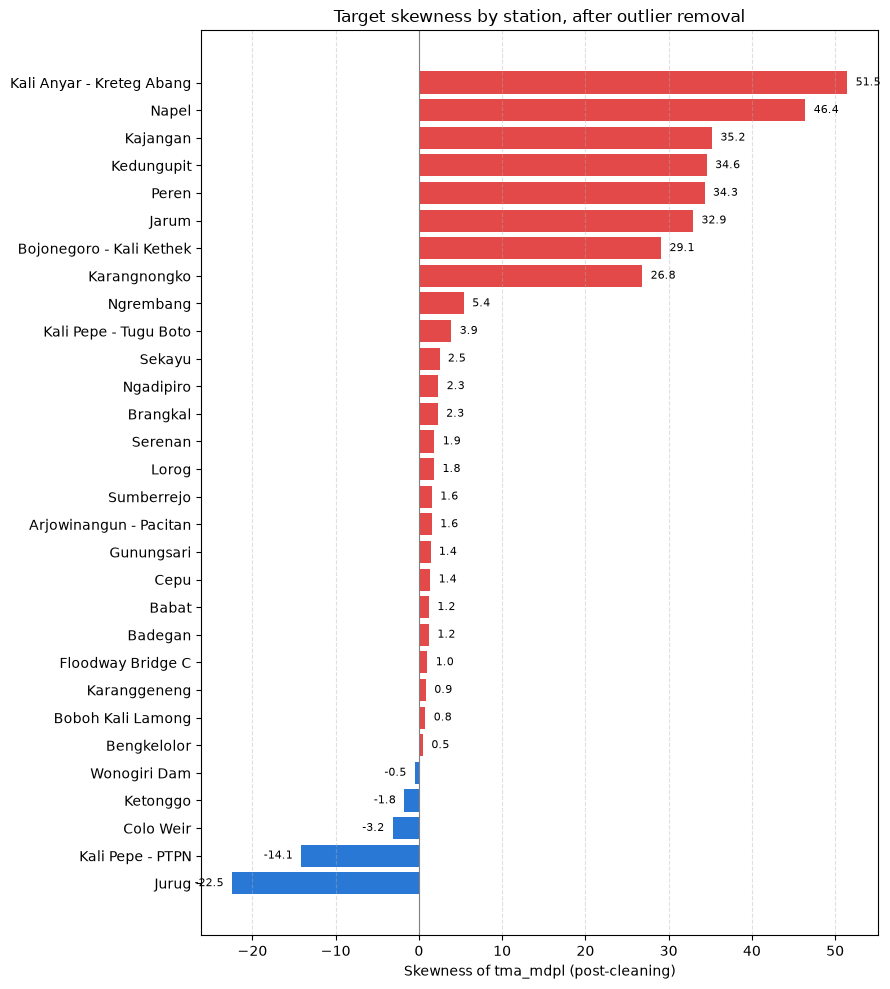


Floodway Bridge C skew before cleaning: 13.29
Floodway Bridge C skew after cleaning:  1.03


In [58]:
# Cell 36: Re-check target skewness after outlier removal (Cell 7 predates the Floodway fix)
skew_per_pos_clean = df.groupby("nama_pos")["tma_mdpl"].skew().sort_values()
colors = ["#2a78d6" if v < 0 else "#e34948" for v in skew_per_pos_clean.values]

fig, ax = plt.subplots(figsize=(9, 10))
bars = ax.barh(skew_per_pos_clean.index, skew_per_pos_clean.values, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Skewness of tma_mdpl (post-cleaning)")
ax.set_title("Target skewness by station, after outlier removal")
ax.grid(axis="x", linestyle="--", alpha=0.4)
for bar, val in zip(bars, skew_per_pos_clean.values):
    ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nFloodway Bridge C skew before cleaning: {skew_per_pos['Floodway Bridge C']:.2f}")
print(f"Floodway Bridge C skew after cleaning:  {skew_per_pos_clean['Floodway Bridge C']:.2f}")

In [59]:
# Cell 37: Merge env features into test, then check missingness per station
env = env.sort_values(["nama_pos", "datetime_parsed"]).reset_index(drop=True)
env["nino_34"] = env.groupby("nama_pos")["nino_34"].ffill()

DROP_COLS = [
    "rainfall_openmeteo_mm", "solar_radiation_mj_m2",
    "built_surface_m2", "landcover_class", "landcover_name", "mjo_active",
]
env = env.drop(columns=[c for c in DROP_COLS if c in env.columns])

env["rolling_rain_48h"] = env.groupby("nama_pos")["rainfall_mm"].transform(lambda x: x.rolling(48, min_periods=1).sum())
env["rolling_rain_72h"] = env.groupby("nama_pos")["rainfall_mm"].transform(lambda x: x.rolling(72, min_periods=1).sum())

env_matched = env[env["datetime_parsed"].dt.hour.isin(TARGET_HOURS)].copy()

ENV_FEATURES = [
    "datetime", "nama_pos",
    "rainfall_mm", "humidity_pct", "wind_direction_deg",
    "dew_point_c", "cloud_cover_pct", "temperature_c",
    "wind_speed_kmh", "rainfall_max_24h_mm",
    "soil_moisture_0_7cm", "soil_moisture_7_28cm",
    "soil_moisture_28_100cm", "soil_moisture_100_255cm",
    "surface_pressure_hpa", "pressure_msl_hpa",
    "rmm1", "rmm2", "mjo_phase", "mjo_amplitude", "nino_34",
    "rolling_rain_48h", "rolling_rain_72h",
]
env_slim = env_matched[[c for c in ENV_FEATURES if c in env_matched.columns]]

train = df.merge(env_slim, on=["datetime", "nama_pos"], how="left")
test = test.merge(
    env_slim, 
    left_on=["datetime_str", "nama_pos"], 
    right_on=["datetime", "nama_pos"],
    how="left"
)

test_missing_cols = test.isnull().sum()
test_missing_cols = test_missing_cols[test_missing_cols > 0]
print("Columns with missing values in test after merge:")
print(test_missing_cols)

env_feature_cols = [c for c in ENV_FEATURES if c not in ("datetime", "nama_pos")]
test_missing_by_pos = test.groupby("nama_pos")[env_feature_cols].apply(lambda g: g.isnull().mean().mean() * 100)
test_missing_by_pos = test_missing_by_pos.sort_values(ascending=False)
print("\nAverage % missing across env features, by station (test set):")
print(test_missing_by_pos.round(1))

print(f"\nStations with >20% average missingness in test: {(test_missing_by_pos > 20).sum()}")

print("\nTrain missing after merge:\n", train.isnull().sum()[train.isnull().sum() > 0])

Columns with missing values in test after merge:
soil_moisture_0_7cm        90
soil_moisture_7_28cm       90
soil_moisture_28_100cm     90
soil_moisture_100_255cm    90
surface_pressure_hpa       90
pressure_msl_hpa           90
rmm1                       90
rmm2                       90
mjo_phase                  90
mjo_amplitude              90
dtype: int64

Average % missing across env features, by station (test set):
nama_pos
Arjowinangun - Pacitan       0.2
Babat                        0.2
Badegan                      0.2
Bengkelolor                  0.2
Boboh Kali Lamong            0.2
Bojonegoro - Kali Kethek     0.2
Brangkal                     0.2
Cepu                         0.2
Colo Weir                    0.2
Floodway Bridge C            0.2
Gunungsari                   0.2
Jarum                        0.2
Jurug                        0.2
Kajangan                     0.2
Kali Anyar - Kreteg Abang    0.2
Kali Pepe - PTPN             0.2
Kali Pepe - Tugu Boto        0.2
Karan

In [60]:
print("df" in dir(), df.shape if "df" in dir() else "MISSING")
print("train" in dir(), train.shape if "train" in dir() else "MISSING")
print("merged" in dir(), merged.shape if "merged" in dir() else "MISSING")
print("env_slim" in dir(), env_slim.shape if "env_slim" in dir() else "MISSING")

True (84395, 7)
True (84395, 28)
True (84395, 34)
True (111060, 23)


In [62]:
# Cell 39: Reindex to a complete 6-hourly grid per station
from itertools import product

full_index = pd.date_range(start="2023-01-01 06:00:00", end="2026-05-18 18:00:00", freq="6h")
full_index = full_index[full_index.hour.isin(TARGET_HOURS)]
all_stations = df["nama_pos"].unique()

full_grid = pd.DataFrame(list(product(full_index, all_stations)), columns=["datetime_parsed", "nama_pos"])

# Missing rows (e.g. the Feb-2025 outage) become NaN in tma_mdpl rather than
# being silently absent, so LightGBM can use its native missing-value handling.
df_reindexed = full_grid.merge(
    df[["datetime_parsed", "nama_pos", "tma_mdpl"]], on=["datetime_parsed", "nama_pos"], how="left"
)

print(f"Shape before reindex: {df.shape}")
print(f"Shape after reindex:  {df_reindexed.shape}")
print(f"Expected rows: {len(full_index)} x {len(all_stations)} = {len(full_index) * len(all_stations)}")

gap_mask = (
    (df_reindexed["datetime_parsed"] >= gap_start) &
    (df_reindexed["datetime_parsed"] <= gap_end) &
    (df_reindexed["nama_pos"] == "Wonogiri Dam")
)
print("\nWonogiri Dam rows in the Feb-2025 gap (should be NaN):")
print(df_reindexed[gap_mask][["datetime_parsed", "tma_mdpl"]].head(10))

Shape before reindex: (84395, 7)
Shape after reindex:  (111060, 3)
Expected rows: 3702 x 30 = 111060

Wonogiri Dam rows in the Feb-2025 gap (should be NaN):
          datetime_parsed  tma_mdpl
68879 2025-02-04 06:00:00       NaN
68909 2025-02-04 12:00:00       NaN
68939 2025-02-04 18:00:00       NaN
68969 2025-02-05 06:00:00       NaN
68999 2025-02-05 12:00:00       NaN
69029 2025-02-05 18:00:00       NaN
69059 2025-02-06 06:00:00       NaN
69089 2025-02-06 12:00:00       NaN
69119 2025-02-06 18:00:00       NaN
69149 2025-02-07 06:00:00       NaN


In [64]:
# Cell 40: Join static hydro/geographic features from river_pos
STATIC_FEATURES = ["nama_pos", "latitude", "longitude", "upland_skm", "dist_dn_km", "dis_av_cms", "main_riv"]

stations_in_df = set(df_reindexed["nama_pos"].unique())
stations_in_river_pos = set(river_pos["nama_pos"].unique())
print(f"Stations in df but not in river_pos: {stations_in_df - stations_in_river_pos}")
print(f"Stations in river_pos but not in df: {stations_in_river_pos - stations_in_df}")

river_pos_with_coords = river_pos.merge(coords[["nama_pos", "latitude", "longitude"]], on="nama_pos")
df_reindexed = df_reindexed.merge(river_pos_with_coords[STATIC_FEATURES], on="nama_pos", how="left")

# Group by main river; anything not in the three confirmed river systems (Cell 31) is isolated.
MAIN_RIV_MAP = {
    50387677: "bengawan_solo",
    50392385: "kali_lamong",
    50419297: "pacitan",
}
df_reindexed["main_riv_group"] = df_reindexed["main_riv"].map(MAIN_RIV_MAP).fillna("isolated")

print("\nmain_riv_group value counts:")
print(df_reindexed["main_riv_group"].value_counts())

Stations in df but not in river_pos: set()
Stations in river_pos but not in df: set()

main_riv_group value counts:
main_riv_group
bengawan_solo    92550
pacitan           7404
kali_lamong       7404
isolated          3702
Name: count, dtype: int64


In [67]:
# Cell 41: Add pressure_diff and merge env_slim into the reindexed grid
env_slim = env_slim.copy()
env_slim["pressure_diff"] = env_slim["pressure_msl_hpa"] - env_slim["surface_pressure_hpa"]

print("pressure_diff sanity check:")
print(env_slim["pressure_diff"].describe())
print(f"Negative values: {(env_slim['pressure_diff'] < 0).sum()}")
# MSL pressure should always be >= surface pressure at positive elevation.

# env_slim keys on the raw "datetime" string column, not datetime_parsed,
# so df_reindexed needs a matching string column to merge on.
df_reindexed["datetime"] = df_reindexed["datetime_parsed"].dt.strftime("%Y-%m-%d %H:%M:%S")

df_full = df_reindexed.merge(env_slim, on=["datetime", "nama_pos"], how="left")

print(f"\nShape after env merge: {df_full.shape}")
print(f"Missing pressure_diff: {df_full['pressure_diff'].isna().sum()}")

pressure_diff sanity check:
count    110970.000000
mean          7.123450
std           5.437394
min           0.200000
25%           1.500000
50%           6.500000
75%          10.800000
max          17.600000
Name: pressure_diff, dtype: float64
Negative values: 0

Shape after env merge: (111060, 33)
Missing pressure_diff: 90


In [68]:
# Cell 41b: Add rolling_rain_7d, consistent with rolling_rain_48h/72h (Cell 37)
# Same source column (rainfall_mm) and same aggregation (sum), window
# converted to 6-hourly steps: 7 days x 24h / 6h = 28 steps.
env["rolling_rain_7d"] = env.groupby("nama_pos")["rainfall_mm"].transform(
    lambda x: x.rolling(28, min_periods=1).sum()
)

print("rolling_rain_7d stats:")
print(env["rolling_rain_7d"].describe())

rolling_rain_7d stats:
count    888480.000000
mean          7.774063
std          10.131641
min           0.000000
25%           0.300000
50%           3.200000
75%          12.400000
max         120.700000
Name: rolling_rain_7d, dtype: float64


In [70]:
# Cell 42: Apply the per-station optimal rainfall lag identified in Cell 16
RAINFALL_LAG_MAP = {
    "Badegan": 0, "Jarum": 0, "Lorog": 0,
    "Jurug": 1, "Ketonggo": 1, "Gunungsari": 1, "Ngadipiro": 1,
    "Peren": 1, "Serenan": 1, "Sekayu": 1,
    "Bengkelolor": 2, "Brangkal": 2, "Kedungupit": 2, "Kajangan": 2,
    "Napel": 3, "Babat": 3, "Karangnongko": 3, "Cepu": 3,
    "Boboh Kali Lamong": 3, "Colo Weir": 3, "Sumberrejo": 3,
    "Karanggeneng": 6, "Ngrembang": 6, "Floodway Bridge C": 6,
    "Wonogiri Dam": 10,
}
# Note: 5 stations below have no env data in env_slim (confirmed by Cell 41
# diagnostic -- 0 rows in env_slim for these names). They are excluded from
# the lag map because apply_station_rainfall_lag would produce empty subsets
# for them, and they carry no rainfall features after the env merge anyway.
# They remain in df_full with NaN rainfall columns.
STATIONS_NO_ENV = {
    "Kali Pepe - Tugu Boto", "Bojonegoro - Kali Kethek",
    "Kali Pepe - PTPN", "Kali Anyar - Kreteg Abang", "Arjowinangun - Pacitan",
}

unmatched = set(RAINFALL_LAG_MAP.keys()) - (set(df_full["nama_pos"].unique()) - STATIONS_NO_ENV)
missing = (set(df_full["nama_pos"].unique()) - STATIONS_NO_ENV) - set(RAINFALL_LAG_MAP.keys())
if unmatched:
    raise ValueError(f"Keys not found in nama_pos: {unmatched}")
if missing:
    raise ValueError(f"Stations missing from RAINFALL_LAG_MAP: {missing}")

def apply_station_rainfall_lag(data, lag_map, rain_col="rainfall_max_24h_mm"):
    """Apply a station-specific lag to rainfall, after reindexing so the
    Feb-2025 gap produces NaN rather than an incorrect cross-gap shift.
    Stations not in lag_map (no env data) pass through unchanged."""
    results = []
    for station, lag in lag_map.items():
        sub = data[data["nama_pos"] == station].sort_values("datetime_parsed").copy()
        sub["rainfall_lag_optimal"] = sub[rain_col] if lag == 0 else sub[rain_col].shift(lag)
        results.append(sub)
    # Stations with no env data: pass through with NaN rainfall_lag_optimal
    no_env = data[data["nama_pos"].isin(STATIONS_NO_ENV)].copy()
    no_env["rainfall_lag_optimal"] = np.nan
    results.append(no_env)
    return pd.concat(results).sort_values(["datetime_parsed", "nama_pos"]).reset_index(drop=True)

df_full = apply_station_rainfall_lag(df_full, RAINFALL_LAG_MAP)

print(f"Stations after lag application: {df_full['nama_pos'].nunique()} (expect 30)")

print("\nCepu - rainfall vs rainfall_lag_optimal (lag 3):")
print(df_full[df_full["nama_pos"] == "Cepu"][
    ["datetime_parsed", "rainfall_max_24h_mm", "rainfall_lag_optimal"]
].head(10))

RAINFALL_COLS = [
    "rainfall_mm", "rainfall_max_24h_mm",
    "rolling_rain_48h", "rolling_rain_72h", "rolling_rain_7d",
    "rainfall_lag_optimal",
]
wonogiri_mask = df_full["nama_pos"] == "Wonogiri Dam"
df_full.loc[wonogiri_mask, RAINFALL_COLS] = np.nan
print(f"\nWonogiri Dam rainfall columns after nulling:")
print(df_full[wonogiri_mask][RAINFALL_COLS].describe())

Stations after lag application: 30 (expect 30)

Cepu - rainfall vs rainfall_lag_optimal (lag 3):
        datetime_parsed  rainfall_max_24h_mm  rainfall_lag_optimal
7   2023-01-01 06:00:00                  0.0                   NaN
37  2023-01-01 12:00:00                  3.1                   NaN
67  2023-01-01 18:00:00                  3.1                   NaN
97  2023-01-02 06:00:00                  3.1                   0.0
127 2023-01-02 12:00:00                  2.4                   3.1
157 2023-01-02 18:00:00                  2.4                   3.1
187 2023-01-03 06:00:00                  2.4                   3.1
217 2023-01-03 12:00:00                  2.6                   2.4
247 2023-01-03 18:00:00                  2.8                   2.4
277 2023-01-04 06:00:00                  2.8                   2.4

Wonogiri Dam rainfall columns after nulling:
       rainfall_mm  rainfall_max_24h_mm  rolling_rain_48h  rolling_rain_72h  rolling_rain_7d  rainfall_lag_optimal
count

In [71]:
# Diagnostic: get the exact nama_pos strings, no guessing
print("All 30 station names in df_full, exact strings:")
for name in sorted(df_full["nama_pos"].unique()):
    print(repr(name))

All 30 station names in df_full, exact strings:
'Arjowinangun - Pacitan'
'Babat'
'Badegan'
'Bengkelolor'
'Boboh Kali Lamong'
'Bojonegoro - Kali Kethek'
'Brangkal'
'Cepu'
'Colo Weir'
'Floodway Bridge C'
'Gunungsari'
'Jarum'
'Jurug'
'Kajangan'
'Kali Anyar - Kreteg Abang'
'Kali Pepe - PTPN'
'Kali Pepe - Tugu Boto'
'Karanggeneng'
'Karangnongko'
'Kedungupit'
'Ketonggo'
'Lorog'
'Napel'
'Ngadipiro'
'Ngrembang'
'Peren'
'Sekayu'
'Serenan'
'Sumberrejo'
'Wonogiri Dam'


In [72]:
# Cell 43: Build the rain_x_soil interaction confirmed useful in Cell 34
df_full["rain_x_soil"] = df_full["rainfall_lag_optimal"] * df_full["soil_moisture_7_28cm"]

print("rain_x_soil stats:")
print(df_full["rain_x_soil"].describe())
print(f"Non-zero values: {(df_full['rain_x_soil'] != 0).sum()}")
print(f"NaN values: {df_full['rain_x_soil'].isna().sum()}")

rain_x_soil stats:
count    88722.000000
mean         1.212237
std          1.735404
min          0.000000
25%          0.030800
50%          0.349200
75%          1.861600
max         17.784400
Name: rain_x_soil, dtype: float64
Non-zero values: 92995
NaN values: 22338


In [73]:
# Cell 44: Add lagged upstream TMA as a predictor for the confirmed downstream pairs
UPSTREAM_PAIRS = [
    ("Jurug", "Serenan", 1),
    ("Cepu", "Sumberrejo", 2),
    ("Cepu", "Karanggeneng", 3),
    ("Bengkelolor", "Boboh Kali Lamong", 1),
]

def build_upstream_tma_features(data, pairs):
    """For each (upstream, downstream, lag) pair: pivot TMA to wide format by
    datetime, shift the upstream series forward by lag steps (step-based,
    not fixed calendar hours -- the grid has a 12h gap between 18:00 and the
    next day's 06:00), then join back onto the downstream station's rows only.

    Leakage guard: shifting is done on the pivoted timeline (not row index),
    so a downstream row at time t only ever sees upstream TMA from lag
    observations earlier in that same station's series, which occurred
    strictly before the downstream target time.
    """
    tma_wide = data.pivot_table(index="datetime_parsed", columns="nama_pos", values="tma_mdpl", aggfunc="first")

    upstream_cols = {}
    for upstream, downstream, lag in pairs:
        col_name = f"upstream_tma_{upstream.lower().replace(' ', '_')}_lag{lag}"
        if upstream not in tma_wide.columns:
            print(f"WARNING: {upstream} not found in the pivot.")
            continue
        upstream_cols[col_name] = tma_wide[upstream].shift(lag)

    upstream_df = pd.DataFrame(upstream_cols, index=tma_wide.index).reset_index()
    data = data.merge(upstream_df, on="datetime_parsed", how="left")

    for upstream, downstream, lag in pairs:
        col_name = f"upstream_tma_{upstream.lower().replace(' ', '_')}_lag{lag}"
        if col_name not in data.columns:
            continue
        data.loc[data["nama_pos"] != downstream, col_name] = np.nan

    return data

df_full = build_upstream_tma_features(df_full, UPSTREAM_PAIRS)

# Verification is position-based (N rows back in the upstream station's own
# sorted series), not a calendar-hour subtraction -- the latter is invalid
# whenever the shift crosses the 18:00 -> 06:00 day-boundary gap.
print("Leakage verification (position-based):")
tma_wide_check = df_full.sort_values("datetime_parsed").pivot_table(
    index="datetime_parsed", columns="nama_pos", values="tma_mdpl", aggfunc="first"
)

for upstream, downstream, lag in UPSTREAM_PAIRS:
    col = f"upstream_tma_{upstream.lower().replace(' ', '_')}_lag{lag}"
    if col not in df_full.columns:
        continue

    sample = df_full[df_full["nama_pos"] == downstream][
        ["datetime_parsed", "tma_mdpl", col]
    ].dropna(subset=[col]).head(5)
    print(f"\n{upstream} -> {downstream} (lag {lag} steps):")
    print(sample)

    t0 = sample.iloc[0]["datetime_parsed"]
    upstream_series = tma_wide_check[upstream]
    pos = upstream_series.index.get_loc(t0)
    expected_val = upstream_series.iloc[pos - lag] if pos - lag >= 0 else np.nan
    feature_val = sample.iloc[0][col]
    matched = pd.notna(expected_val) and abs(expected_val - feature_val) < 1e-6

    print(f"  downstream t: {t0} | upstream position: {pos} -> {pos - lag}")
    print(f"  upstream TMA at position {pos - lag}: {expected_val}")
    print(f"  feature value: {feature_val:.4f} | match: {matched}")

upstream_feature_cols = [
    f"upstream_tma_{u.lower().replace(' ', '_')}_lag{l}" for u, d, l in UPSTREAM_PAIRS
    if f"upstream_tma_{u.lower().replace(' ', '_')}_lag{l}" in df_full.columns
]
print(f"\nUpstream TMA columns: {upstream_feature_cols}")
print("NaN rate per column (expect high - only the matching downstream station gets values):")
print(df_full[upstream_feature_cols].isna().mean().round(3))

Leakage verification (position-based):

Jurug -> Serenan (lag 1 steps):
        datetime_parsed  tma_mdpl  upstream_tma_jurug_lag1
57  2023-01-01 12:00:00     87.14                80.260000
87  2023-01-01 18:00:00     87.25                80.280956
117 2023-01-02 06:00:00     87.28                79.930000
147 2023-01-02 12:00:00     87.12                80.500000
177 2023-01-02 18:00:00     87.02                80.160000
  downstream t: 2023-01-01 12:00:00 | upstream position: 1 -> 0
  upstream TMA at position 0: 80.26
  feature value: 80.2600 | match: True

Cepu -> Sumberrejo (lag 2 steps):
        datetime_parsed  tma_mdpl  upstream_tma_cepu_lag2
88  2023-01-01 18:00:00   8.96000               18.790000
118 2023-01-02 06:00:00   8.13653               18.588557
148 2023-01-02 12:00:00   7.74000               18.400000
178 2023-01-02 18:00:00   7.36000               18.070000
208 2023-01-03 06:00:00   6.88000               17.990000
  downstream t: 2023-01-01 18:00:00 | upstream posit

In [84]:
# Cell 45: Build remaining time-based and staleness features
df_full["bulan"] = df_full["datetime_parsed"].dt.month
df_full["day_of_year"] = df_full["datetime_parsed"].dt.dayofyear

df_full["horizon_days"] = (df_full["datetime_parsed"] - TRAIN_TEST_CUTOFF).dt.total_seconds() / 86400

horizon_bins = [-np.inf, 30, 90, np.inf]
horizon_labels = ["near", "mid", "far"]
df_full["horizon_bucket"] = pd.cut(df_full["horizon_days"], bins=horizon_bins, labels=horizon_labels)

def days_since_last_valid(group):
    group = group.sort_values("datetime_parsed")
    valid_time = group["datetime_parsed"].where(group["tma_mdpl"].notna())
    last_valid = valid_time.ffill()
    return (group["datetime_parsed"] - last_valid).dt.total_seconds() / 86400

df_full["days_since_last_valid_tma"] = (
    df_full.groupby("nama_pos", group_keys=False).apply(days_since_last_valid)
)

print(f"Stations in df_full: {df_full['nama_pos'].nunique()} (expect 30)")
print(f"horizon_bucket distribution:\n{df_full['horizon_bucket'].value_counts()}")
print(f"\ndays_since_last_valid_tma max: {df_full['days_since_last_valid_tma'].max():.1f} days")
print(f"NaN staleness rows: {df_full['days_since_last_valid_tma'].isna().sum()}")
print(f"\nStations with no rainfall_lag_optimal (expect 6: Wonogiri + 5 no-env):")
print(df_full.groupby("nama_pos")["rainfall_lag_optimal"].apply(lambda x: x.isna().all()))

Stations in df_full: 30 (expect 30)
horizon_bucket distribution:
horizon_bucket
near    91980
far     13680
mid      5400
Name: count, dtype: int64

days_since_last_valid_tma max: 242.0 days
NaN staleness rows: 1772

Stations with no rainfall_lag_optimal (expect 6: Wonogiri + 5 no-env):
nama_pos
Arjowinangun - Pacitan        True
Babat                        False
Badegan                      False
Bengkelolor                  False
Boboh Kali Lamong            False
Bojonegoro - Kali Kethek      True
Brangkal                     False
Cepu                         False
Colo Weir                    False
Floodway Bridge C            False
Gunungsari                   False
Jarum                        False
Jurug                        False
Kajangan                     False
Kali Anyar - Kreteg Abang     True
Kali Pepe - PTPN              True
Kali Pepe - Tugu Boto         True
Karanggeneng                 False
Karangnongko                 False
Kedungupit                   False
Ket

In [85]:
# Cell 45b: Add remaining columns required by FEATURES_EXP007 that are not
# yet present in df_full after Cell 45.
# hour: already available in datetime_parsed, just not extracted to a column yet.
df_full["hour"] = df_full["datetime_parsed"].dt.hour

# tma_mean_pos / tma_std_pos / ac_lag1_pos: placeholder columns, filled
# per-fold inside the training loop (Cell 47) to avoid leakage. Initialized
# to NaN here so FEATURES_EXP007 column selection does not raise KeyError.
df_full["tma_mean_pos"] = np.nan
df_full["tma_std_pos"] = np.nan
df_full["ac_lag1_pos"] = np.nan

missing_from_df_full = [f for f in FEATURES_EXP007 if f not in df_full.columns]
print(f"Features still missing from df_full after Cell 45b: {missing_from_df_full}")
# Expect: []

Features still missing from df_full after Cell 45b: []


In [78]:
# Cell 46: Config, feature set, and expanding-window validation folds
import lightgbm as lgb

EXP_ID = "exp007"
SEED = 42

FEATURES_EXP007 = [
    "bulan", "day_of_year", "hour",
    "nama_pos", "latitude", "longitude", "main_riv_group",
    "upland_skm", "dist_dn_km", "dis_av_cms",
    "tma_mean_pos", "tma_std_pos", "ac_lag1_pos",
    "soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm",
    "rainfall_mm", "rainfall_lag_optimal",
    "rolling_rain_48h", "rolling_rain_72h", "rolling_rain_7d",
    "humidity_pct", "dew_point_c", "cloud_cover_pct",
    "temperature_c", "wind_speed_kmh", "wind_direction_deg",
    "pressure_msl_hpa", "pressure_diff",
    "rmm1", "rmm2", "mjo_amplitude", "mjo_phase", "nino_34",
    "rain_x_soil",
    "upstream_tma_jurug_lag1", "upstream_tma_cepu_lag2",
    "upstream_tma_cepu_lag3", "upstream_tma_bengkelolor_lag1",
    "horizon_days", "horizon_bucket",
    "days_since_last_valid_tma",
]

LGB_PARAMS = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 127,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "seed": SEED,
    "deterministic": True,
    "verbosity": -1,
}

# Expanding window: each fold trains on everything up to train_end, validates
# on the following season. Fold 2's window matches the actual train/test cutoff.
FOLDS = [
    {
        "fold": 1,
        "train_end": pd.Timestamp("2024-08-31 18:00:00"),
        "val_start": pd.Timestamp("2024-10-01 06:00:00"),
        "val_end": pd.Timestamp("2025-05-31 18:00:00"),
    },
    {
        "fold": 2,
        "train_end": pd.Timestamp("2025-08-31 18:00:00"),
        "val_start": pd.Timestamp("2025-09-19 06:00:00"),
        "val_end": pd.Timestamp("2026-05-18 18:00:00"),
    },
]

In [ ]:
# Cell 47: Train/validate across expanding-window folds
train_only = df_full[df_full["datetime_parsed"] <= TRAIN_TEST_CUTOFF].copy()

# mjo_phase is discrete without a meaningful linear ordering, so it is
# treated as categorical alongside station identity, same as nama_pos/main_riv_group.
CAT_COLS = ["nama_pos", "main_riv_group", "mjo_phase"]
for col in CAT_COLS:
    if col in FEATURES_EXP007:
        train_only[col] = train_only[col].astype("category")

oof_preds = np.full(len(train_only), np.nan)
fold_rmses = []
best_iters = []

for fold_cfg in FOLDS:
    fold_num = fold_cfg["fold"]

    # tma_mdpl is already NaN across the Feb-2025 gap after reindexing (Cell 39),
    # so the gap mask here is redundant with the NaN-row drop below, but kept
    # explicit for clarity about which rows are intentionally excluded.
    train_mask = (
        (train_only["datetime_parsed"] <= fold_cfg["train_end"]) &
        ~((train_only["datetime_parsed"] >= gap_start) & (train_only["datetime_parsed"] <= gap_end))
    )
    val_mask = (
        (train_only["datetime_parsed"] >= fold_cfg["val_start"]) &
        (train_only["datetime_parsed"] <= fold_cfg["val_end"]) &
        ~((train_only["datetime_parsed"] >= gap_start) & (train_only["datetime_parsed"] <= gap_end))
    )

    # Rows with a missing target cannot contribute to training or scoring.
    train_mask &= train_only["tma_mdpl"].notna()
    val_mask &= train_only["tma_mdpl"].notna()

    # Per-fold station stats, computed on the train split only to avoid leakage.
    train_split = train_only.loc[train_mask]
    stat_map = train_split.groupby("nama_pos")["tma_mdpl"].agg(["mean", "std"]).rename(
        columns={"mean": "tma_mean_pos", "std": "tma_std_pos"}
    )
    ac_map = train_split.groupby("nama_pos")["tma_mdpl"].apply(lambda x: x.autocorr(lag=1)).rename("ac_lag1_pos")

    for mask in (train_mask, val_mask):
        pos_series = train_only.loc[mask, "nama_pos"]
        train_only.loc[mask, "tma_mean_pos"] = pos_series.map(stat_map["tma_mean_pos"])
        train_only.loc[mask, "tma_std_pos"] = pos_series.map(stat_map["tma_std_pos"])
        train_only.loc[mask, "ac_lag1_pos"] = pos_series.map(ac_map)

    X_tr = train_only.loc[train_mask, FEATURES_EXP007]
    y_tr = train_only.loc[train_mask, "tma_mdpl"]
    X_val = train_only.loc[val_mask, FEATURES_EXP007]
    y_val = train_only.loc[val_mask, "tma_mdpl"]

    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CAT_COLS, free_raw_data=False)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=CAT_COLS, free_raw_data=False)

    model = lgb.train(
        LGB_PARAMS, dtrain, num_boost_round=2000, valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
    )

    val_pred = model.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    fold_rmses.append(fold_rmse)
    best_iters.append(model.best_iteration)
    oof_preds[val_mask.values] = val_pred

    print(f"Fold {fold_num} RMSE: {fold_rmse:.4f} | best_iter: {model.best_iteration}")

[100]	valid_0's rmse: 1.32844
Fold 1 RMSE: 1.3092 | best_iter: 118


ValueError: Input data must be 2 dimensional and non empty.